# TDC 2.0 Dataset — Exploratory Data Analysis

**Dataset structure:**
- Racks: R0501–R0606, each with sub-systems PA and PB
- Months: 2022-09 through 2023-02 (6 months)
- File types per rack/month:
  - `PM-<rack>-<date>.csv` — aggregate power meter (kW, V, A, PF, Hz)
  - `PM01..PM24-<date>.csv` — individual cell power meters
  - `THFM/THFB/THBB/THBT/THBM-<date>.csv` — temperature & humidity sensors
- Sampling: ~30s intervals

In [ ]:
import os, glob, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# DATA_ROOT comes from the installed rack_forecast package, so this notebook
# works no matter which folder Jupyter is launched from.
from rack_forecast.paths import DATA_ROOT
print('Racks:', sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith('R')]))

## 1. Data Loading Utilities

In [2]:
PM_COLS  = ['timestamp', 'kW', 'V', 'A', 'PF', 'Hz']
TH_COLS  = ['timestamp', 'temp_C', 'humidity_pct']

def load_files(pattern, cols):
    """Load all CSVs matching glob pattern into a single DataFrame."""
    files = sorted(glob.glob(str(DATA_ROOT / pattern)))
    frames = []
    for f in files:
        try:
            df = pd.read_csv(f, sep='\t', header=None, names=cols,
                             parse_dates=['timestamp'])
            # tag with source metadata
            parts = Path(f).parts
            df['rack']   = parts[-3]   # e.g. R0605-PA
            df['sensor'] = Path(f).stem.split('-')[0]  # e.g. PM, THFM
            frames.append(df)
        except Exception as e:
            print(f'  skip {f}: {e}')
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

def load_agg_pm(rack):
    """Load aggregate PM files for one rack across all months."""
    pat = f'{rack}/*/PM-{rack}-*.csv'
    return load_files(pat, PM_COLS)

def load_th(rack, prefix):
    """Load temperature/humidity files (e.g. THFM, THBB) for one rack."""
    pat = f'{rack}/*/{prefix}-*.csv'
    return load_files(pat, TH_COLS)

print('Utilities ready.')

Utilities ready.


## 2. Dataset Inventory

In [3]:
racks = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith('R')])
inventory = []
for rack in racks:
    for month_dir in sorted((DATA_ROOT / rack).iterdir()):
        files = list(month_dir.glob('*.csv'))
        file_types = sorted(
            set(
                re.split(r'[-_]', f.stem)[0] 
                for f in files
            )
        )
        inventory.append({'rack': rack, 'month': month_dir.name,
                          'n_files': len(files), 'types': ', '.join(file_types)})

inv_df = pd.DataFrame(inventory)
print(inv_df.to_string(index=False))

    rack   month  n_files                                                                                                                                                                      types
R0501-PA 2022-09      870 PM, PM01, PM02, PM03, PM04, PM05, PM06, PM07, PM08, PM09, PM10, PM11, PM12, PM13, PM14, PM15, PM16, PM17, PM18, PM19, PM20, PM21, PM22, PM23, PM24, THBB, THFB, THFM, THFT
R0501-PA 2022-10      899 PM, PM01, PM02, PM03, PM04, PM05, PM06, PM07, PM08, PM09, PM10, PM11, PM12, PM13, PM14, PM15, PM16, PM17, PM18, PM19, PM20, PM21, PM22, PM23, PM24, THBB, THFB, THFM, THFT
R0501-PA 2022-11      870 PM, PM01, PM02, PM03, PM04, PM05, PM06, PM07, PM08, PM09, PM10, PM11, PM12, PM13, PM14, PM15, PM16, PM17, PM18, PM19, PM20, PM21, PM22, PM23, PM24, THBB, THFB, THFM, THFT
R0501-PA 2022-12      899 PM, PM01, PM02, PM03, PM04, PM05, PM06, PM07, PM08, PM09, PM10, PM11, PM12, PM13, PM14, PM15, PM16, PM17, PM18, PM19, PM20, PM21, PM22, PM23, PM24, THBB, THFB, THFM, THFT
R0501-PA 2023-0

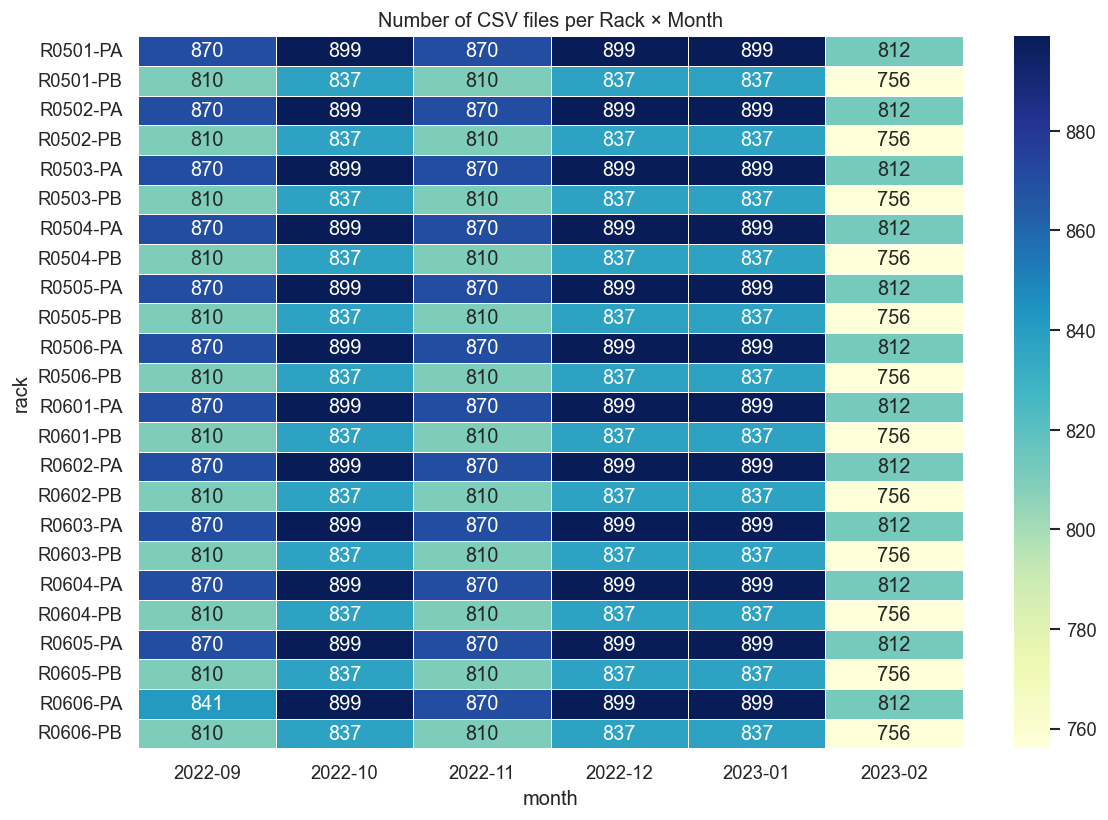

In [4]:
# File count heatmap across racks × months
pivot = inv_df.pivot(index='rack', columns='month', values='n_files')
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', ax=ax, linewidths=.5)
ax.set_title('Number of CSV files per Rack × Month')
plt.tight_layout()
plt.show()

## 3. Aggregate Power Meter (PM) Analysis

Focus on one representative rack first, then compare across racks.

In [5]:
FOCUS_RACK = 'R0605-PA'
pm = load_agg_pm(FOCUS_RACK)
pm = pm.sort_values('timestamp').reset_index(drop=True)
print(f'Loaded {len(pm):,} records  |  {pm.timestamp.min()} → {pm.timestamp.max()}')
pm.head()

Loaded 521,232 records  |  2022-09-01 00:00:01 → 2023-02-28 23:59:30


,timestamp,kW,V,A,PF,Hz,rack,sensor
0,2022-09-01 00:00:01,0.563,229.4,2.79,0.88,659.8,R0605-PA,PM
1,2022-09-01 00:00:30,0.514,229.1,2.57,0.87,659.8,R0605-PA,PM
2,2022-09-01 00:01:00,0.535,229.7,2.66,0.88,659.8,R0605-PA,PM
3,2022-09-01 00:01:31,0.511,229.7,2.56,0.87,659.8,R0605-PA,PM
4,2022-09-01 00:02:00,0.535,229.1,2.65,0.88,659.8,R0605-PA,PM


In [6]:
pm.describe().round(3)

,timestamp,kW,V,A,PF,Hz
count,521232,521232.000,521232.000,521232.000,521232.000,521232.000
mean,2022-11-30 12:07:13.182065,0.470,229.741,2.370,0.865,1687.048
min,2022-09-01 00:00:01,0.406,228.400,2.120,0.810,659.800
25%,2022-10-16 06:17:22.750000,0.453,229.500,2.290,0.860,1169.400
50%,2022-11-30 12:11:45.500000,0.469,229.700,2.360,0.870,1681.600
75%,2023-01-14 18:05:38.250000,0.487,230.000,2.440,0.870,2201.400
max,2023-02-28 23:59:30,0.691,230.600,3.310,0.910,2729.500
std,NaN,0.027,0.410,0.113,0.010,596.362


In [7]:
# Missing values
print('Null counts:')
print(pm.isnull().sum())
print(f'\nDuplicate timestamps: {pm.duplicated("timestamp").sum()}')

Null counts:
timestamp    0
kW           0
V            0
A            0
PF           0
Hz           0
rack         0
sensor       0
dtype: int64

Duplicate timestamps: 0


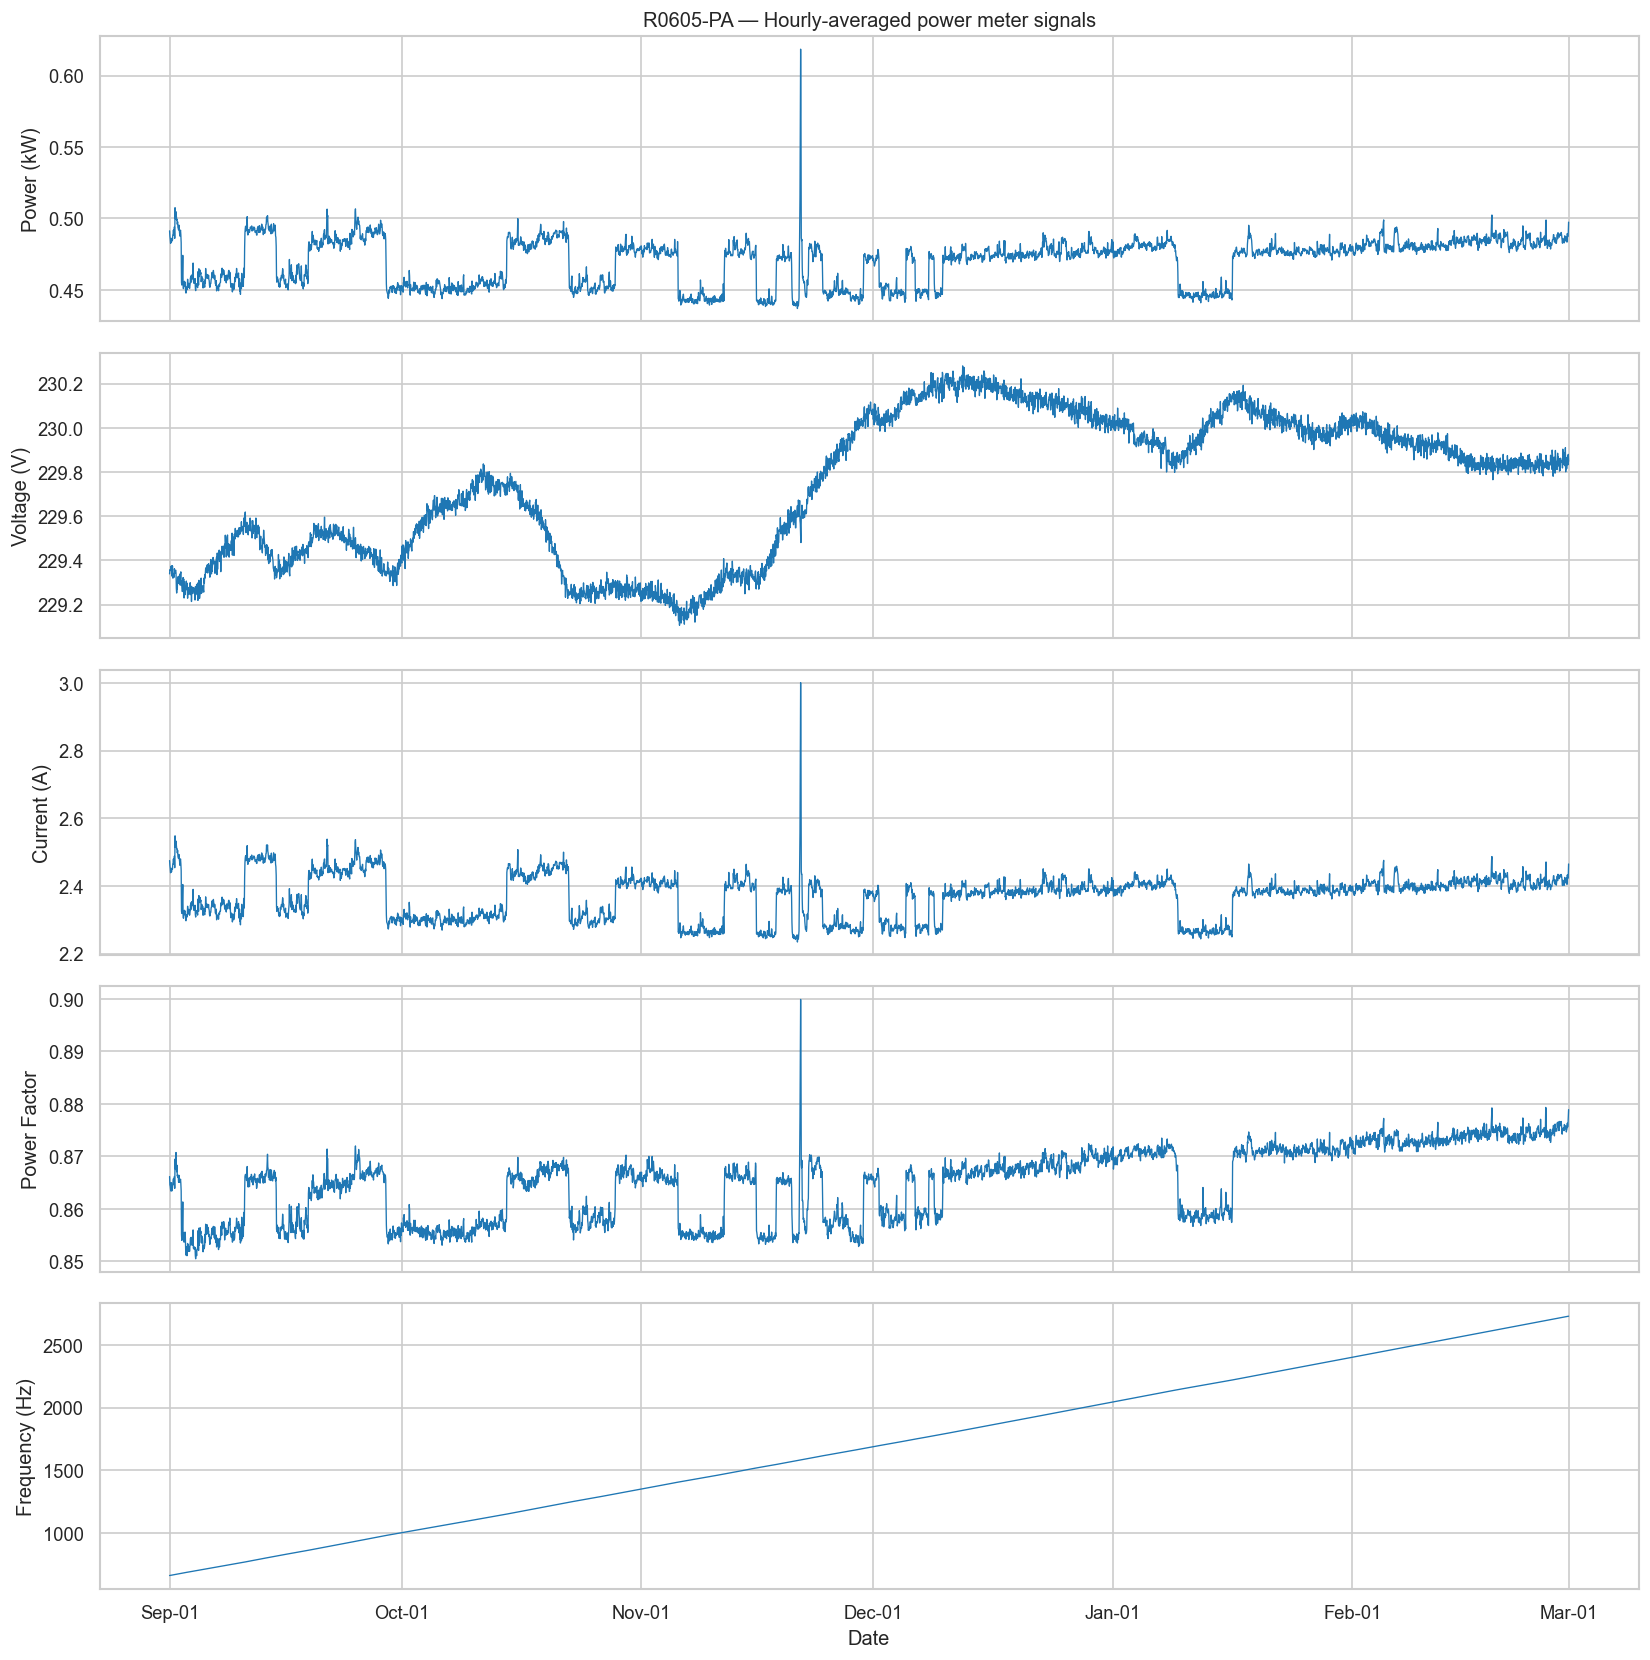

In [8]:
# Time-series overview — resample to 1-hour mean for readability
pm_h = pm.set_index('timestamp')[['kW', 'V', 'A', 'PF', 'Hz']].resample('1h').mean()

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
labels = ['Power (kW)', 'Voltage (V)', 'Current (A)', 'Power Factor', 'Frequency (Hz)']
for ax, col, label in zip(axes, ['kW', 'V', 'A', 'PF', 'Hz'], labels):
    ax.plot(pm_h.index, pm_h[col], lw=0.8)
    ax.set_ylabel(label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
axes[0].set_title(f'{FOCUS_RACK} — Hourly-averaged power meter signals')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

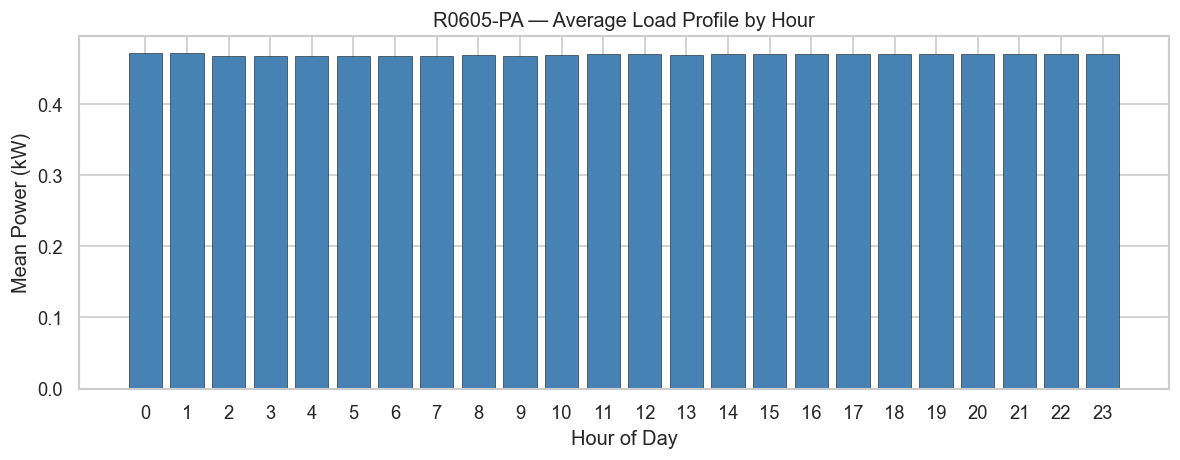

In [10]:
# Hourly load profile (average kW by hour-of-day)
pm['hour'] = pm['timestamp'].dt.hour
pm['dow']  = pm['timestamp'].dt.day_name()

hourly_mean = pm.groupby('hour')['kW'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_mean.index, hourly_mean.values, color='steelblue', edgecolor='k', linewidth=0.3)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Power (kW)')
ax.set_title(f'{FOCUS_RACK} — Average Load Profile by Hour')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

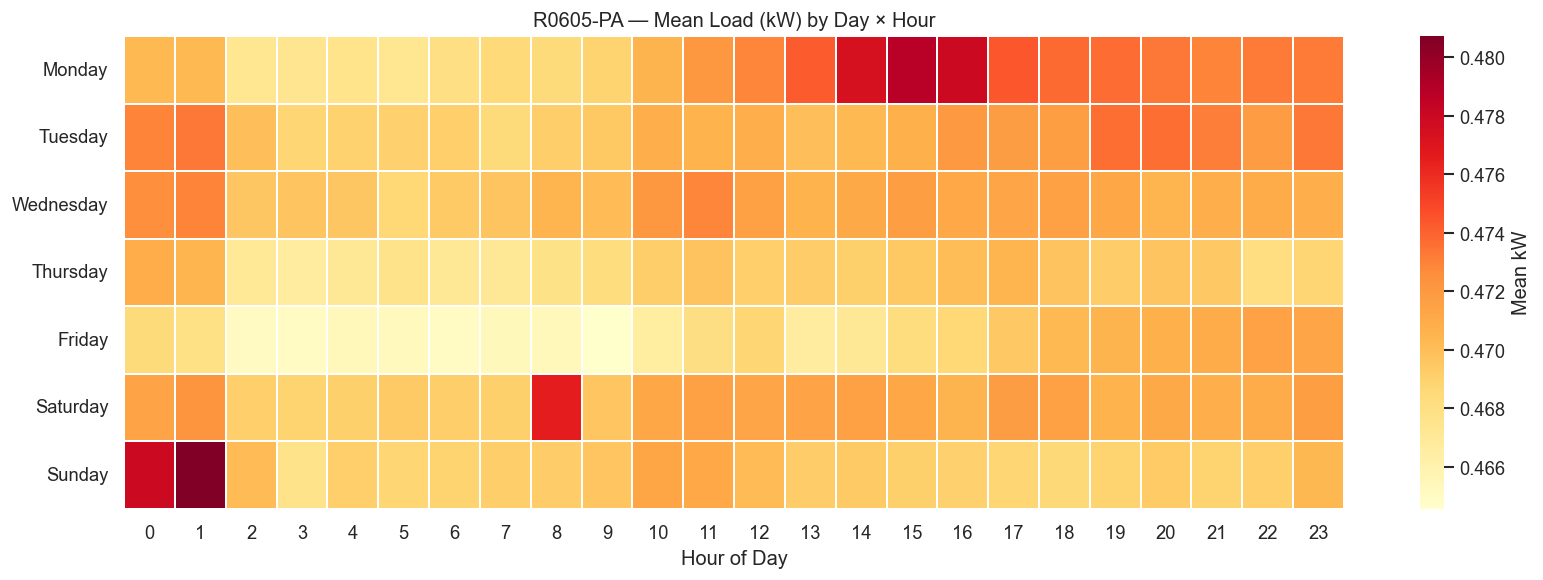

In [11]:
# Day-of-week heatmap: hour × dow
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot_dow = pm.groupby(['dow','hour'])['kW'].mean().unstack('hour')
pivot_dow = pivot_dow.reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_dow, ax=ax, cmap='YlOrRd', linewidths=0.2,
            cbar_kws={'label': 'Mean kW'})
ax.set_title(f'{FOCUS_RACK} — Mean Load (kW) by Day × Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

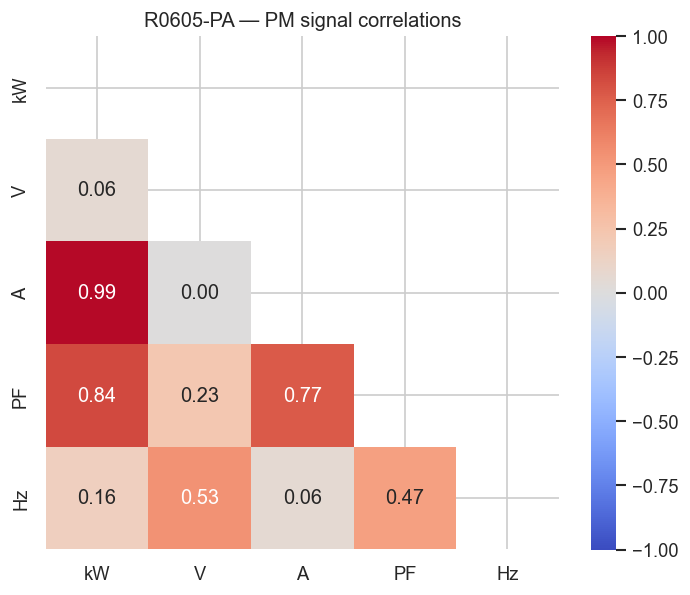

In [12]:
# Correlation matrix for PM signals
fig, ax = plt.subplots(figsize=(6, 5))
corr = pm[cols_pm].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title(f'{FOCUS_RACK} — PM signal correlations')
plt.tight_layout()
plt.show()

## 4. Temperature & Humidity Analysis

In [13]:
# PA rack has THFM (front-middle), THFB (front-bottom), THBB (back-bottom)
# PB rack has THBM (back-middle), THBT (back-top)
th_sensors_pa = ['THFM', 'THFB', 'THBB']
th_dfs = {}
for s in th_sensors_pa:
    df = load_th(FOCUS_RACK, s)
    if not df.empty:
        df = df.sort_values('timestamp').reset_index(drop=True)
        th_dfs[s] = df
        print(f'{s}: {len(df):,} records  |  T range [{df.temp_C.min():.1f}, {df.temp_C.max():.1f}] °C  |  '
              f'RH range [{df.humidity_pct.min():.0f}, {df.humidity_pct.max():.0f}] %')

THFM: 521,232 records  |  T range [17.9, 45.5] °C  |  RH range [32, 77] %
THFB: 521,232 records  |  T range [18.5, 41.8] °C  |  RH range [32, 79] %
THBB: 521,232 records  |  T range [22.6, 48.1] °C  |  RH range [23, 60] %


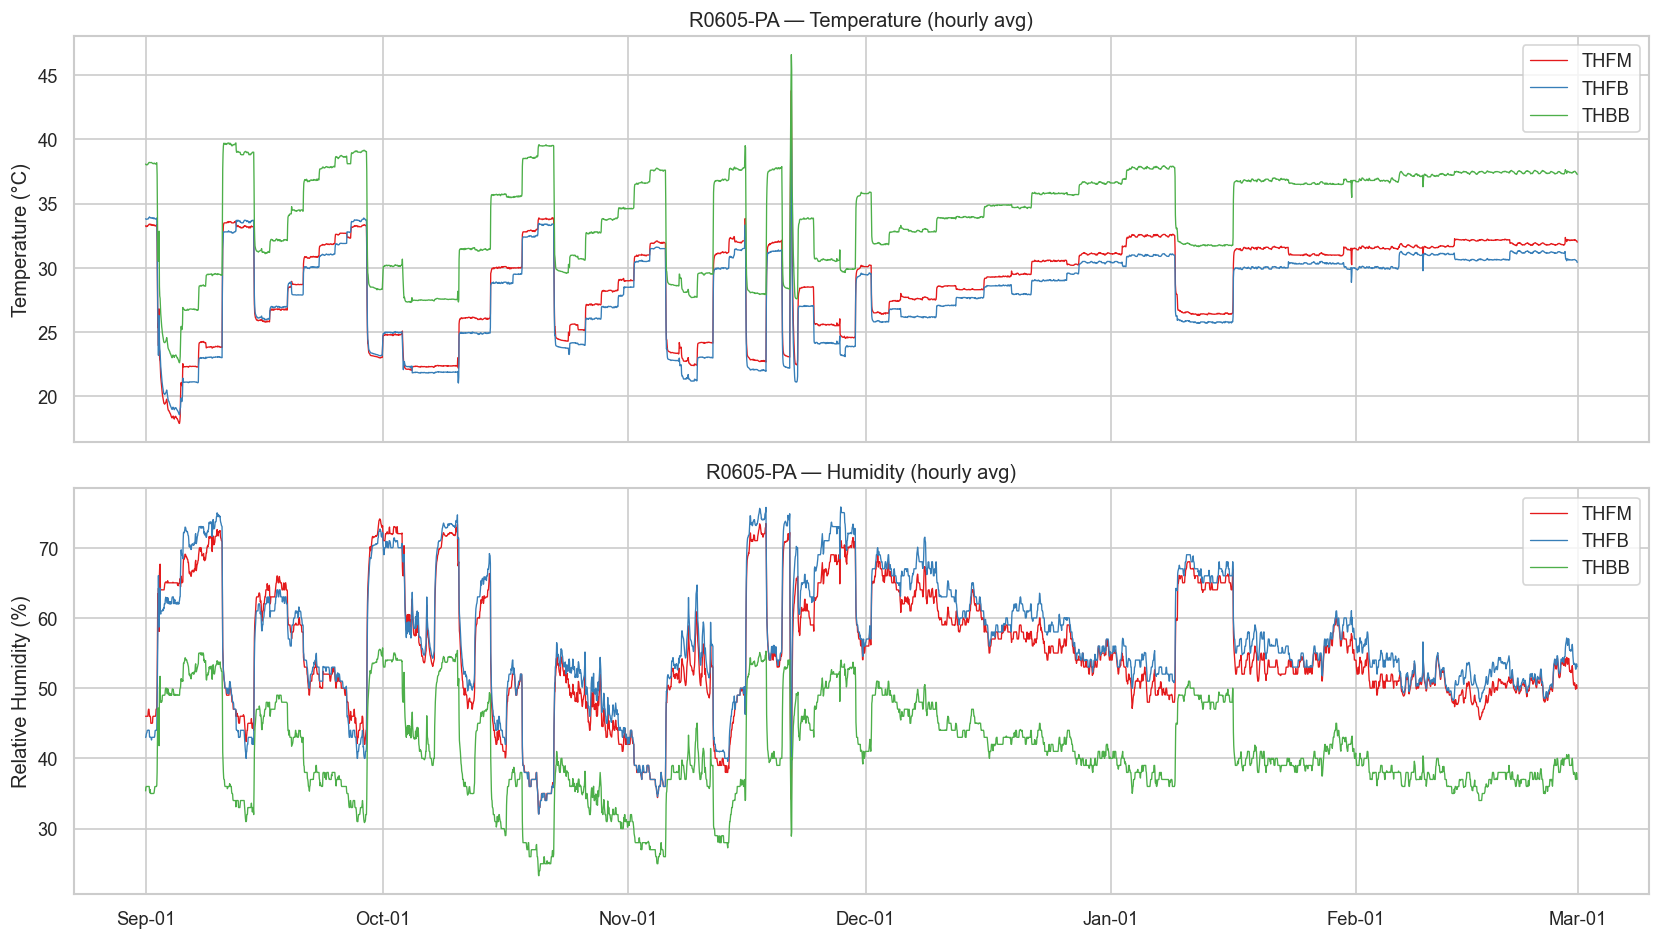

In [14]:
# Temperature time-series for all sensors on focus rack
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colors = ['#e41a1c','#377eb8','#4daf4a']
for (s, df), c in zip(th_dfs.items(), colors):
    df_h = df.set_index('timestamp')[['temp_C','humidity_pct']].resample('1h').mean()
    axes[0].plot(df_h.index, df_h['temp_C'], label=s, lw=0.8, color=c)
    axes[1].plot(df_h.index, df_h['humidity_pct'], label=s, lw=0.8, color=c)

axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].set_title(f'{FOCUS_RACK} — Temperature (hourly avg)')
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].legend()
axes[1].set_title(f'{FOCUS_RACK} — Humidity (hourly avg)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.tight_layout()
plt.show()

C:\Users\quang\AppData\Local\Temp\ipykernel_35432\805838520.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=th_combined, x='sensor', y='temp_C', ax=axes[0], palette='Set2', inner='quartile')
C:\Users\quang\AppData\Local\Temp\ipykernel_35432\805838520.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=th_combined, x='sensor', y='humidity_pct', ax=axes[1], palette='Set2', inner='quartile')


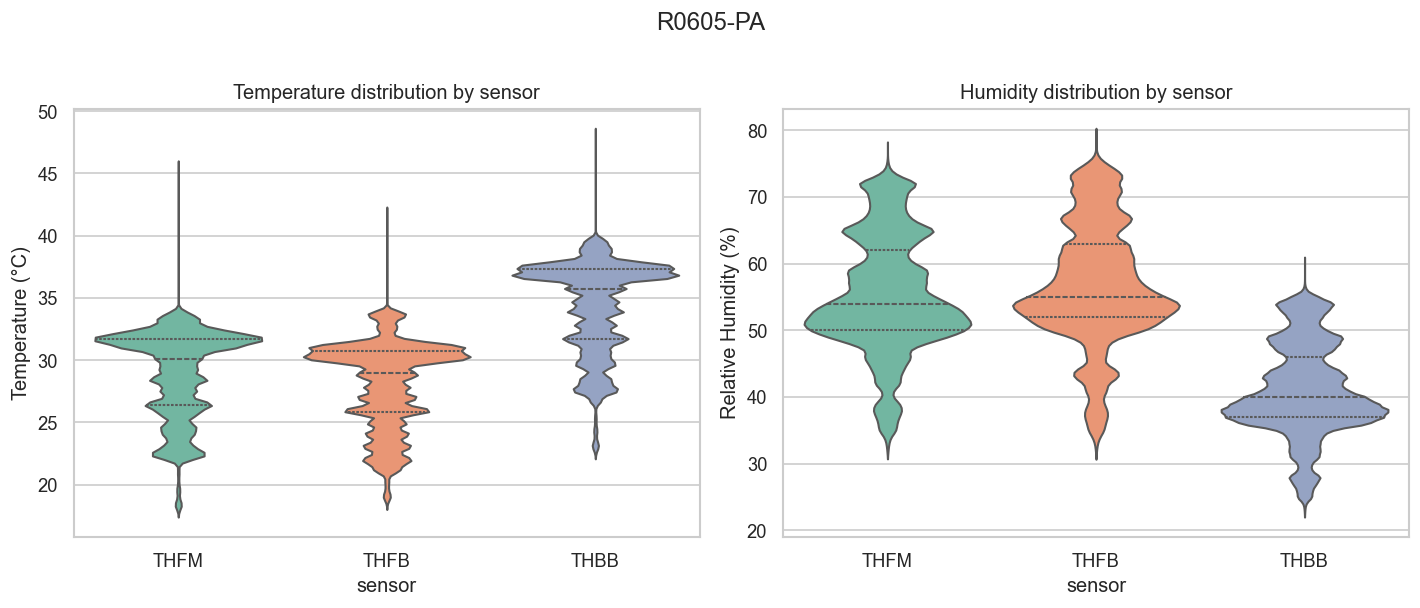

In [15]:
# Violin plots: temperature distribution by sensor
th_combined = pd.concat(
    [df[['temp_C','humidity_pct']].assign(sensor=s) for s, df in th_dfs.items()]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=th_combined, x='sensor', y='temp_C', ax=axes[0], palette='Set2', inner='quartile')
axes[0].set_title('Temperature distribution by sensor')
axes[0].set_ylabel('Temperature (°C)')
sns.violinplot(data=th_combined, x='sensor', y='humidity_pct', ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_title('Humidity distribution by sensor')
axes[1].set_ylabel('Relative Humidity (%)')
plt.suptitle(FOCUS_RACK, y=1.01)
plt.tight_layout()
plt.show()

## 5. R0605-PB Sensor Analysis (Back-Top & Back-Middle)

In [16]:
PB_RACK = 'R0605-PB'
pb_sensors = ['THBT', 'THBM']
pb_dfs = {}
for s in pb_sensors:
    df = load_th(PB_RACK, s)
    if not df.empty:
        df = df.sort_values('timestamp').reset_index(drop=True)
        pb_dfs[s] = df
        print(f'{s}: {len(df):,} records  |  '
              f'T [{df.temp_C.min():.1f}, {df.temp_C.max():.1f}] °C  |  '
              f'RH [{df.humidity_pct.min():.0f}, {df.humidity_pct.max():.0f}] %')

THBT: 521,232 records  |  T [21.6, 47.8] °C  |  RH [25, 63] %
THBM: 521,232 records  |  T [19.2, 48.0] °C  |  RH [24, 69] %


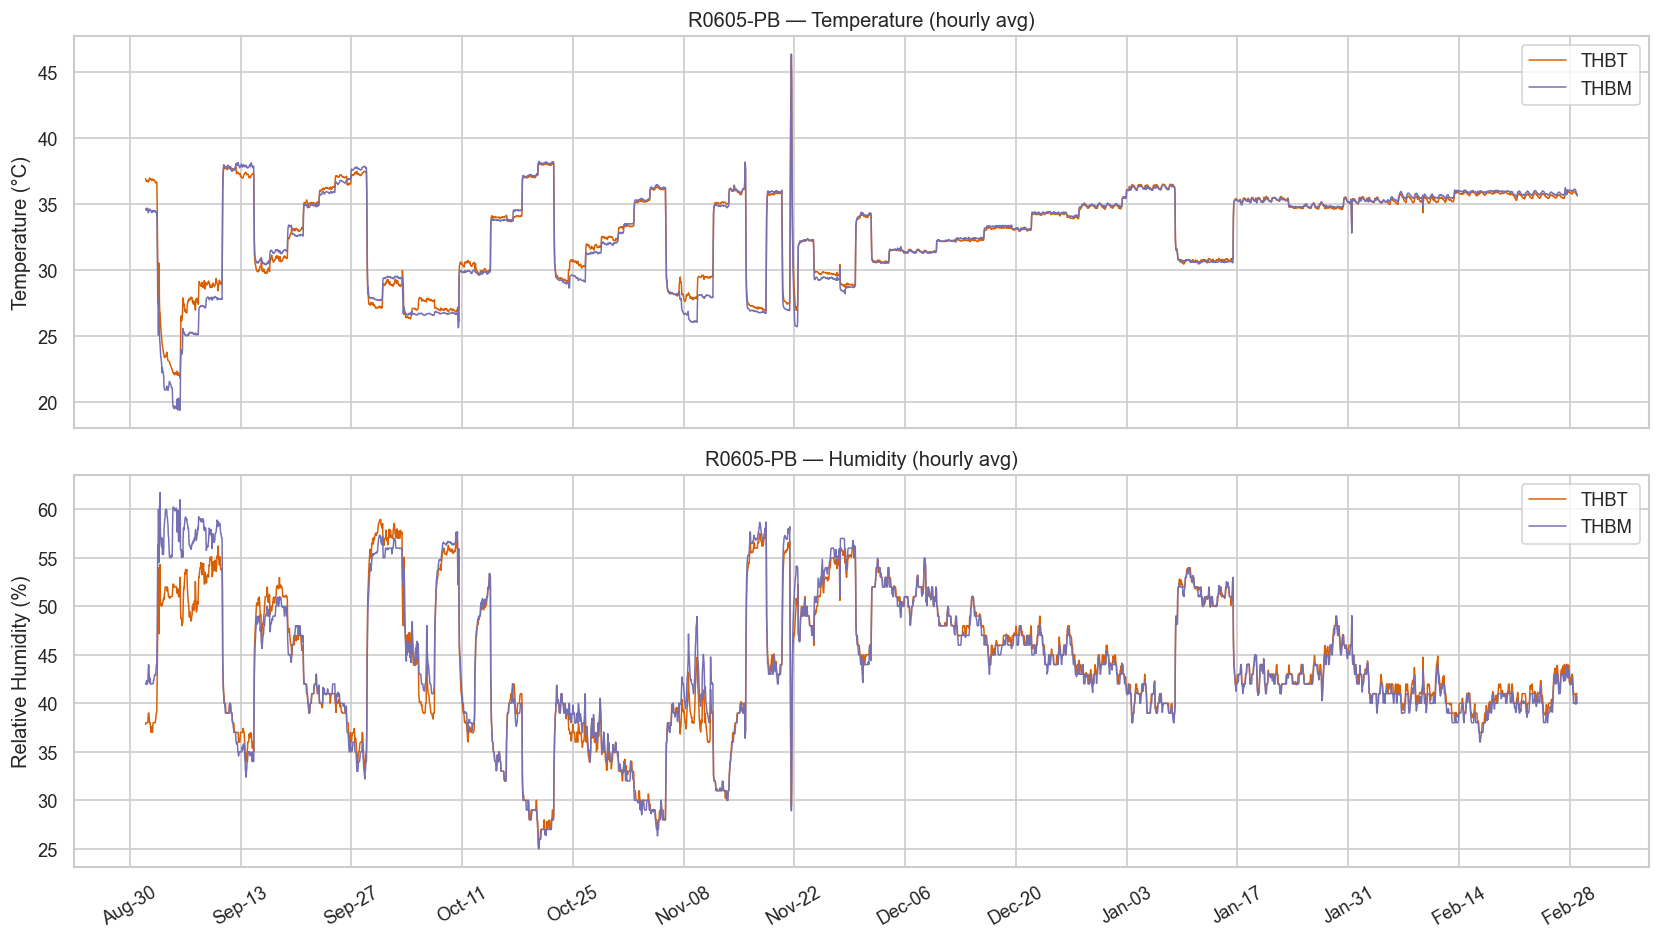

In [17]:
# Time-series: temperature and humidity for PB sensors
pb_colors = {'THBT': '#d95f02', 'THBM': '#7570b3'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for s, df in pb_dfs.items():
    df_h = df.set_index('timestamp')[['temp_C', 'humidity_pct']].resample('1h').mean()
    axes[0].plot(df_h.index, df_h['temp_C'], label=s, lw=0.9, color=pb_colors[s])
    axes[1].plot(df_h.index, df_h['humidity_pct'], label=s, lw=0.9, color=pb_colors[s])

axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'{PB_RACK} — Temperature (hourly avg)')
axes[0].legend()
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].set_title(f'{PB_RACK} — Humidity (hourly avg)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\quang\AppData\Local\Temp\ipykernel_35432\722550491.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pb_combined, x='sensor', y='temp_C', ax=axes[0],
C:\Users\quang\AppData\Local\Temp\ipykernel_35432\722550491.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pb_combined, x='sensor', y='humidity_pct', ax=axes[1],


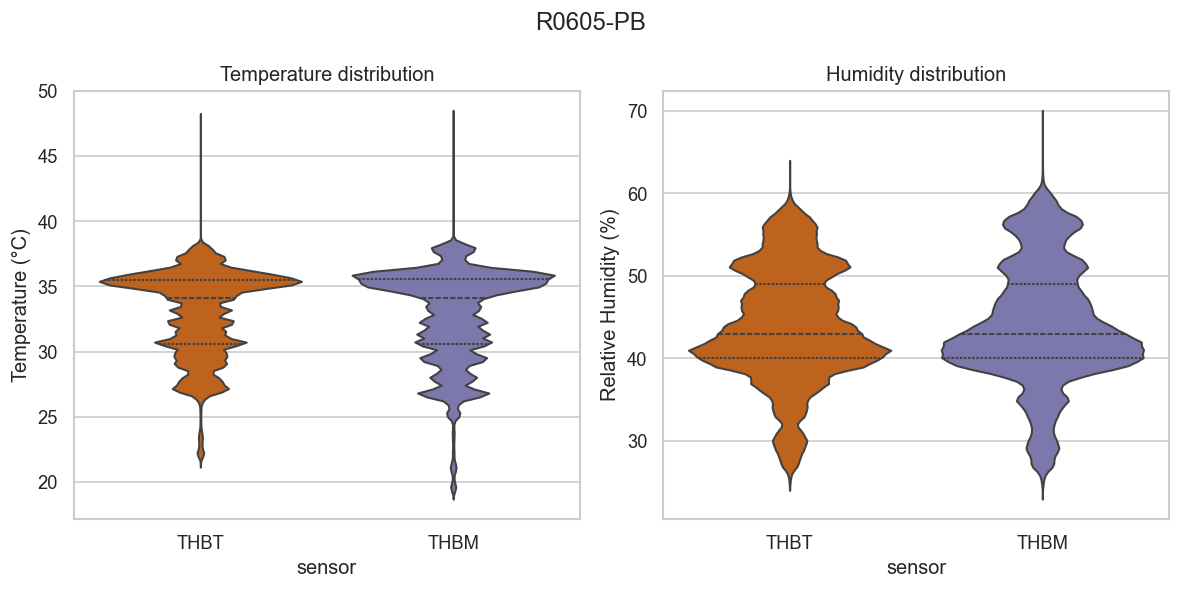

In [18]:
# Violin plots: PB sensor distributions
pb_combined = pd.concat(
    [df[['temp_C', 'humidity_pct']].assign(sensor=s) for s, df in pb_dfs.items()]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.violinplot(data=pb_combined, x='sensor', y='temp_C', ax=axes[0],
               palette=pb_colors, inner='quartile')
axes[0].set_title('Temperature distribution')
axes[0].set_ylabel('Temperature (°C)')
sns.violinplot(data=pb_combined, x='sensor', y='humidity_pct', ax=axes[1],
               palette=pb_colors, inner='quartile')
axes[1].set_title('Humidity distribution')
axes[1].set_ylabel('Relative Humidity (%)')
plt.suptitle(PB_RACK)
plt.tight_layout()
plt.show()

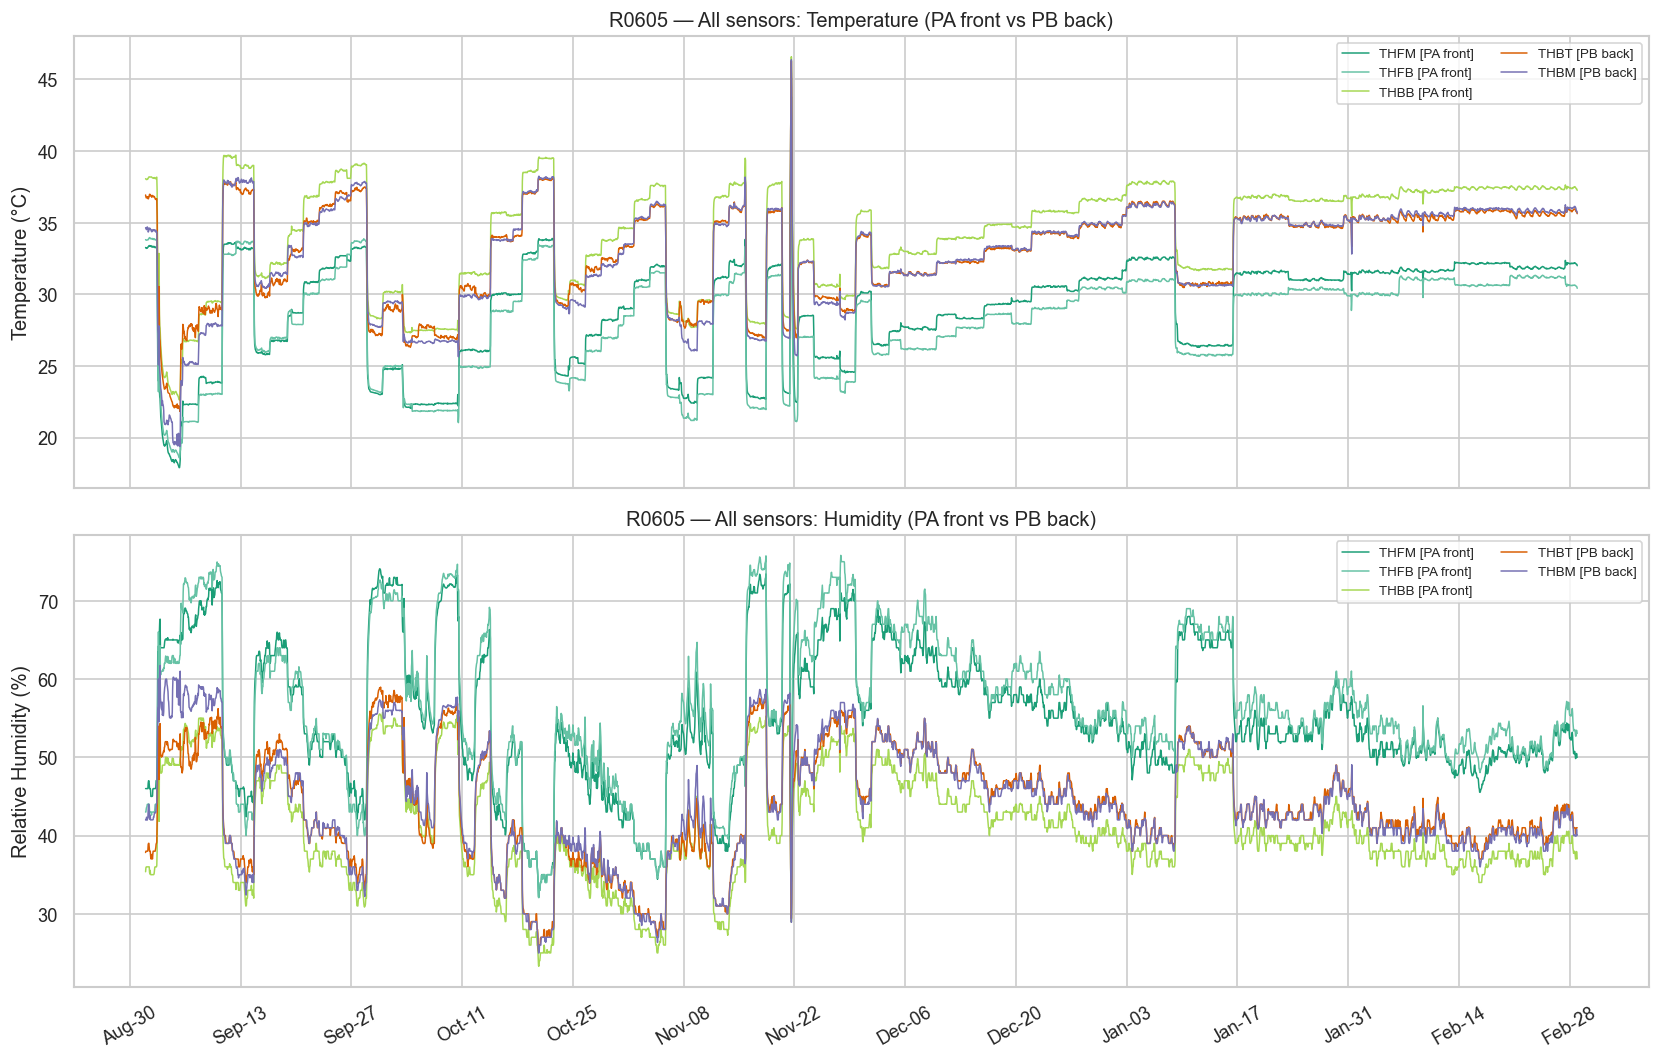

In [19]:
# Compare all 5 sensors (PA front + PB back) on one plot
pa_pb_colors = {
    'THFM': '#1b9e77', 'THFB': '#66c2a5', 'THBB': '#a6d854',
    'THBT': '#d95f02', 'THBM': '#7570b3'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for s, df in {**th_dfs, **pb_dfs}.items():
    df_h = df.set_index('timestamp')[['temp_C', 'humidity_pct']].resample('1h').mean()
    side = 'PA front' if s in th_dfs else 'PB back'
    axes[0].plot(df_h.index, df_h['temp_C'], label=f'{s} [{side}]',
                 lw=0.9, color=pa_pb_colors[s])
    axes[1].plot(df_h.index, df_h['humidity_pct'], label=f'{s} [{side}]',
                 lw=0.9, color=pa_pb_colors[s])

axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('R0605 — All sensors: Temperature (PA front vs PB back)')
axes[0].legend(ncol=2, fontsize=8)
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].set_title('R0605 — All sensors: Humidity (PA front vs PB back)')
axes[1].legend(ncol=2, fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Cross-Rack Comparison

In [20]:
# Load aggregate PM for all PA racks — daily mean kW
all_pm = []
pa_racks = [r for r in racks if r.endswith('-PA')]
for rack in pa_racks:
    df = load_agg_pm(rack)
    if not df.empty:
        df['date'] = df['timestamp'].dt.date
        daily = df.groupby('date')['kW'].mean().reset_index()
        daily['rack'] = rack
        all_pm.append(daily)

all_pm_df = pd.concat(all_pm, ignore_index=True)
all_pm_df['date'] = pd.to_datetime(all_pm_df['date'])
print(f'Loaded {len(pa_racks)} PA racks, {len(all_pm_df):,} rack-day records')

Loaded 12 PA racks, 2,171 rack-day records


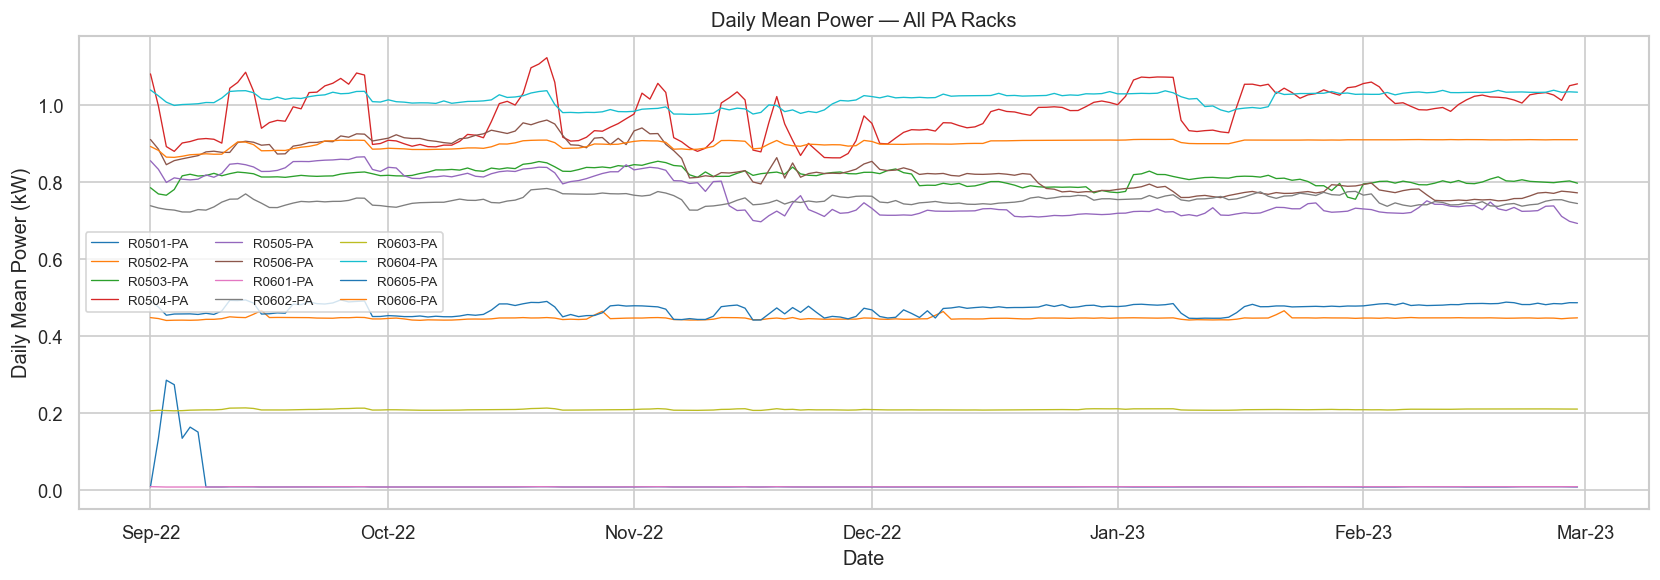

In [21]:
# Daily mean kW across all PA racks
fig, ax = plt.subplots(figsize=(14, 5))
for rack, grp in all_pm_df.groupby('rack'):
    ax.plot(grp['date'], grp['kW'], lw=0.8, label=rack)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Mean Power (kW)')
ax.set_title('Daily Mean Power — All PA Racks')
ax.legend(ncol=3, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.tight_layout()
plt.show()

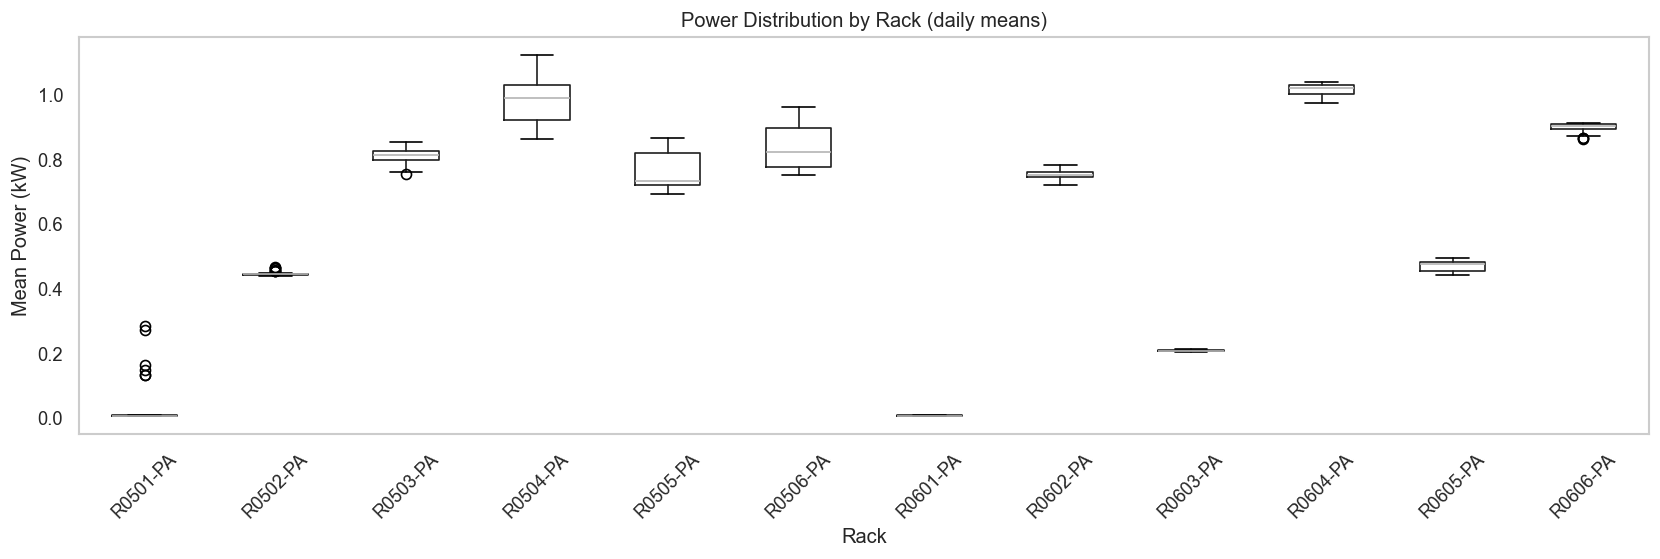

In [22]:
# Box plots: kW distribution per rack
fig, ax = plt.subplots(figsize=(14, 5))
all_pm_df.boxplot(column='kW', by='rack', ax=ax, rot=45, grid=False)
ax.set_title('Power Distribution by Rack (daily means)')
ax.set_xlabel('Rack')
ax.set_ylabel('Mean Power (kW)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Individual Cell Power Meters (PM01–PM24)

In [23]:
# Load all 24 cell PMs for the focus rack, one representative day
SAMPLE_DATE = '2022-09-01'
cell_dfs = {}
for i in range(1, 25):
    label = f'PM{i:02d}'
    pat = str(DATA_ROOT / FOCUS_RACK / '2022-09' / f'{label}-{SAMPLE_DATE}.csv')
    if os.path.exists(pat):
        df = pd.read_csv(pat, sep='\t', header=None, names=PM_COLS, parse_dates=['timestamp'])
        cell_dfs[label] = df.sort_values('timestamp').reset_index(drop=True)

print(f'Loaded {len(cell_dfs)} cell PM files for {FOCUS_RACK} on {SAMPLE_DATE}')

Loaded 24 cell PM files for R0605-PA on 2022-09-01


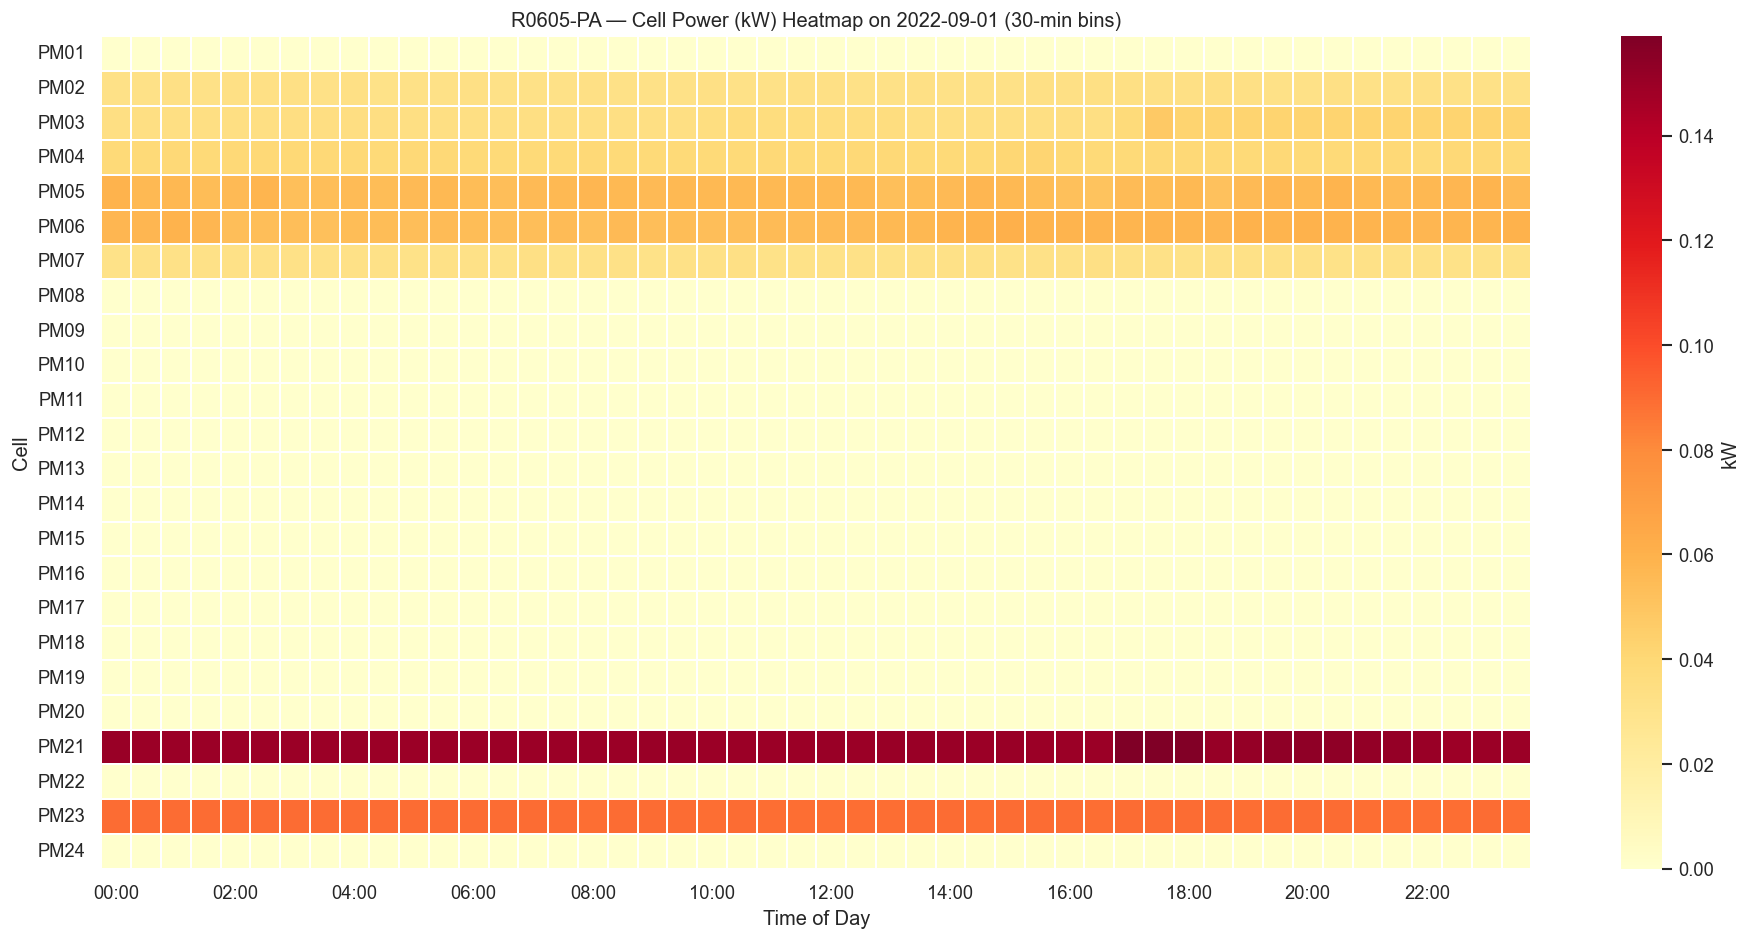

In [24]:
# Heatmap: power per cell over the day (30-min bins)
cell_matrix = {}
for label, df in cell_dfs.items():
    df_r = df.set_index('timestamp')['kW'].resample('30min').mean()
    cell_matrix[label] = df_r

cell_df = pd.DataFrame(cell_matrix).T
cell_df.columns = [c.strftime('%H:%M') for c in cell_df.columns]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cell_df, ax=ax, cmap='YlOrRd', linewidths=0.2,
            cbar_kws={'label': 'kW'}, xticklabels=4)
ax.set_title(f'{FOCUS_RACK} — Cell Power (kW) Heatmap on {SAMPLE_DATE} (30-min bins)')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Cell')
plt.tight_layout()
plt.show()

In [25]:
# Summary statistics per cell
cell_stats = pd.DataFrame({
    label: df['kW'].describe()
    for label, df in cell_dfs.items()
}).T.round(3)
cell_stats

,count,mean,std,min,25%,50%,75%,max
PM01,2880.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
PM02,2880.0,0.032,0.002,0.027,0.031,0.032,0.033,0.047
PM03,2880.0,0.037,0.004,0.032,0.034,0.034,0.041,0.085
PM04,2880.0,0.039,0.004,0.031,0.037,0.038,0.039,0.073
PM05,2880.0,0.056,0.019,0.029,0.040,0.044,0.079,0.091
PM06,2880.0,0.057,0.009,0.028,0.050,0.058,0.064,0.080
PM07,2880.0,0.032,0.003,0.028,0.031,0.031,0.031,0.063
PM08,2880.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
PM09,2880.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
PM10,2880.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000


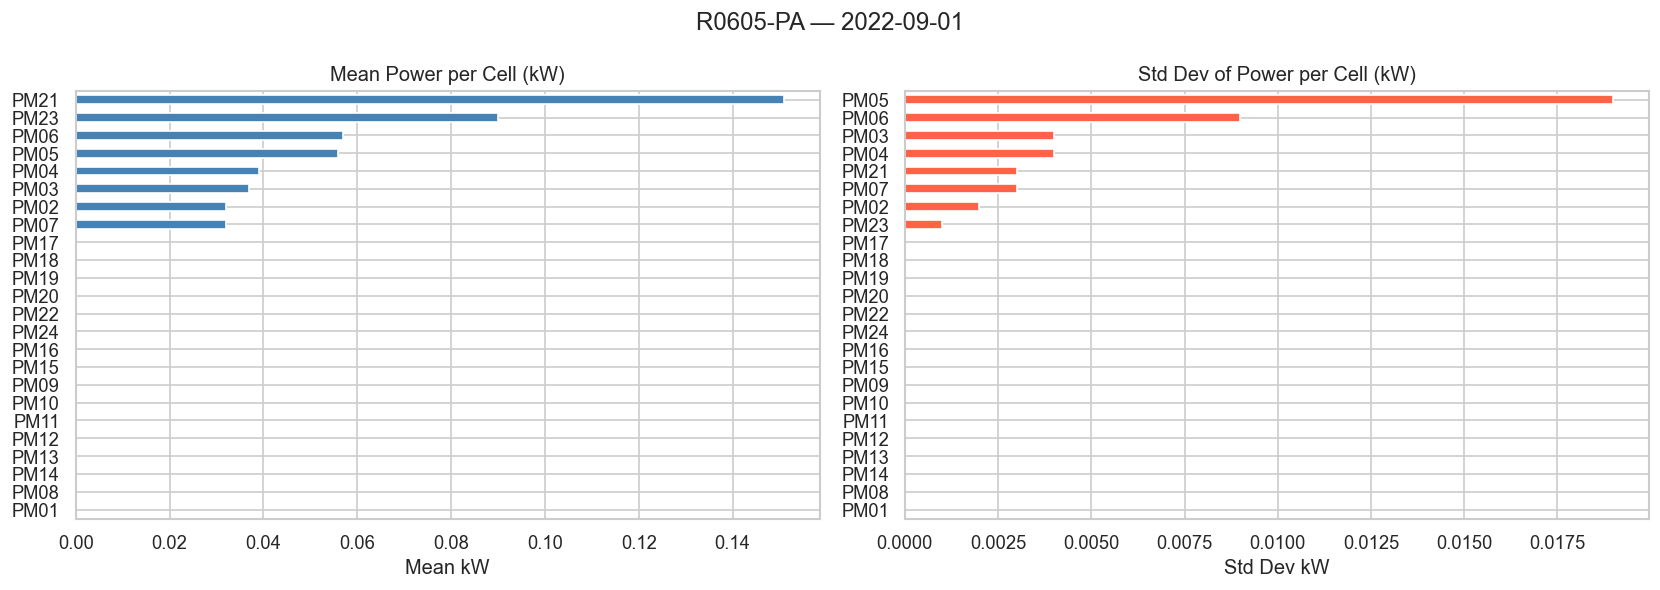

In [26]:
# Which cells contribute most / have highest variance?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cell_stats['mean'].sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Mean Power per Cell (kW)')
axes[0].set_xlabel('Mean kW')
cell_stats['std'].sort_values().plot.barh(ax=axes[1], color='tomato')
axes[1].set_title('Std Dev of Power per Cell (kW)')
axes[1].set_xlabel('Std Dev kW')
plt.suptitle(f'{FOCUS_RACK} — {SAMPLE_DATE}')
plt.tight_layout()
plt.show()

## 8. Anomaly / Outlier Detection

In [27]:
# Flag samples where kW > mean + 3*std or kW < 0
mean_kw, std_kw = pm['kW'].mean(), pm['kW'].std()
anomalies = pm[(pm['kW'] > mean_kw + 3*std_kw) | (pm['kW'] < 0)].copy()
print(f'Total records: {len(pm):,}  |  Anomalies (3-sigma + negatives): {len(anomalies):,} ({100*len(anomalies)/len(pm):.2f}%)')
anomalies[['timestamp','kW','V','A','PF']].describe().round(3)

Total records: 521,232  |  Anomalies (3-sigma + negatives): 1,123 (0.22%)


,timestamp,kW,V,A,PF
count,1123,1123.000,1123.000,1123.000,1123.000
mean,2022-11-12 13:41:48.222618,0.570,229.590,2.794,0.889
min,2022-09-01 00:00:01,0.551,228.900,2.650,0.870
25%,2022-09-25 07:05:00.500000,0.553,229.300,2.720,0.880
50%,2022-11-21 14:10:01,0.556,229.600,2.740,0.890
75%,2022-12-17 19:25:00,0.566,229.800,2.785,0.890
max,2023-02-28 22:50:01,0.691,230.600,3.310,0.910
std,NaN,0.030,0.357,0.128,0.009


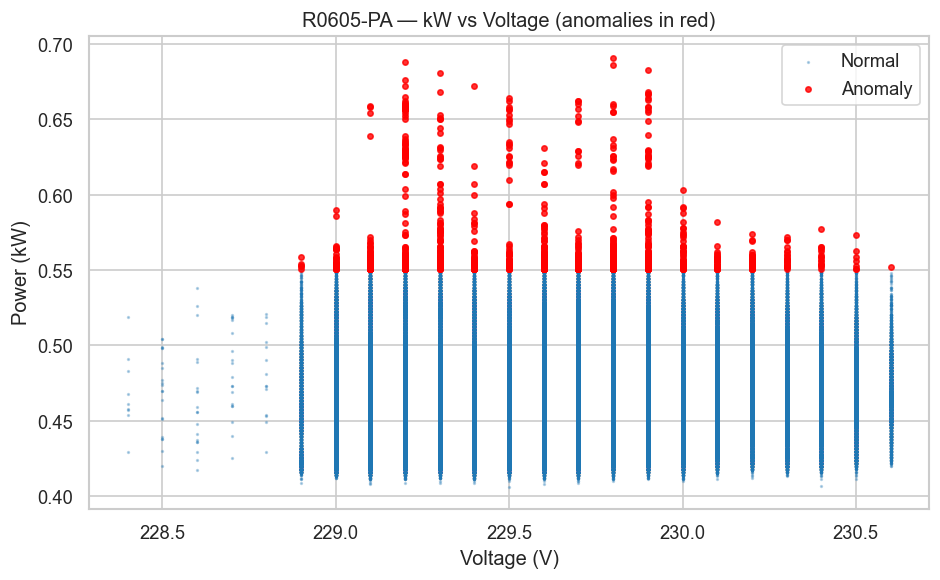

In [28]:
# Scatter: kW vs V, highlighting anomalies
fig, ax = plt.subplots(figsize=(8, 5))
normal = pm[~pm.index.isin(anomalies.index)]
ax.scatter(normal['V'], normal['kW'], s=1, alpha=0.3, label='Normal')
ax.scatter(anomalies['V'], anomalies['kW'], s=10, c='red', alpha=0.8, label='Anomaly')
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Power (kW)')
ax.set_title(f'{FOCUS_RACK} — kW vs Voltage (anomalies in red)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Monthly Energy Summary

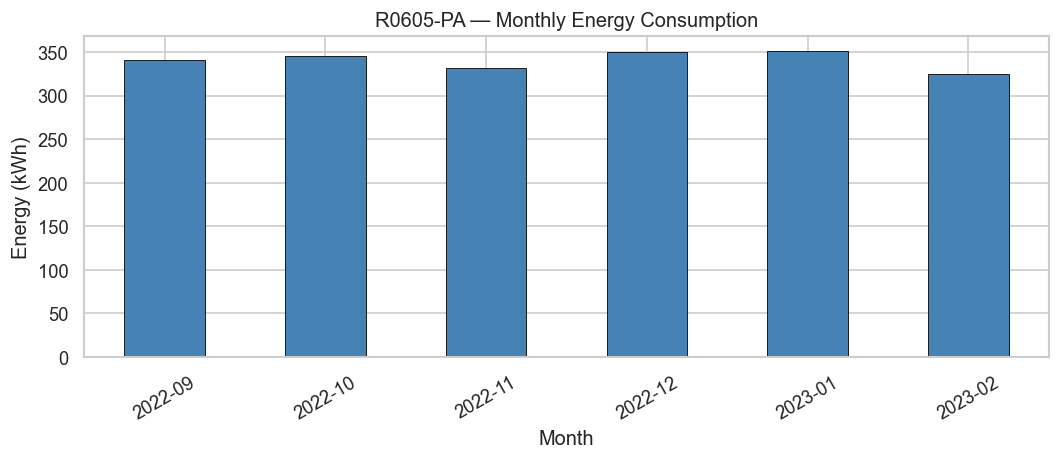

month
2022-09    340.9
2022-10    344.9
2022-11    331.7
2022-12    349.7
2023-01    350.6
2023-02    324.6
Freq: M


In [29]:
# Approximate energy (kWh) = kW * (delta_t in hours)
pm_sorted = pm.sort_values('timestamp').copy()
pm_sorted['dt_h'] = pm_sorted['timestamp'].diff().dt.total_seconds().fillna(30) / 3600
pm_sorted['dt_h'] = pm_sorted['dt_h'].clip(0, 0.1)  # cap at 6-min gap
pm_sorted['kWh']  = pm_sorted['kW'] * pm_sorted['dt_h']
pm_sorted['month'] = pm_sorted['timestamp'].dt.to_period('M')

monthly_energy = pm_sorted.groupby('month')['kWh'].sum()
fig, ax = plt.subplots(figsize=(9, 4))
monthly_energy.plot.bar(ax=ax, color='steelblue', edgecolor='k', linewidth=0.5)
ax.set_title(f'{FOCUS_RACK} — Monthly Energy Consumption')
ax.set_ylabel('Energy (kWh)')
ax.set_xlabel('Month')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(monthly_energy.rename('kWh').round(1).to_string())

## 10. SensorGW Overview

| GW | Sensors | Measurement |
|----|---------|-------------|
| GW-1 | SAAV1, SAAV2 | Air velocity (m/s) |
| GW-1 | SAT1 | Supply air temperature (°C) |
| GW-2 | OATH1/2, RATH1/2, SATH1/2 | Temp (°C) + Humidity (%) |
| GW-2 | DPS1/2/3 | Differential pressure (Pa?) |
| GW-3 & GW-4 | T-DL/EL/LL/SL-* | Temperature (°C) |
| GW-3 & GW-4 | PS-DL/EL/LL/SL-* | Pressure (PSI) |
| GW-5 | PCU-x-P-CF/EF | Single-phase power (W, V, A, PF, kWh) |
| GW-5 | PCU-x-P-CM/CP* | Three-phase power (W, V_L1, V_L2, V_L3, kWh) |

In [30]:
def load_gw(gw_num, sensor, cols):
    pat = str(DATA_ROOT / f'SensorGW-{gw_num}' / '*' / f'{sensor}-*.csv')
    files = sorted(glob.glob(pat))
    frames = [pd.read_csv(f, sep='\t', header=None, names=cols,
                           parse_dates=['timestamp'], na_values=['-'])
              for f in files]
    return pd.concat(frames, ignore_index=True).sort_values('timestamp') if frames else pd.DataFrame()

print('GW loader ready.')

GW loader ready.


### GW-1: Air Velocity (SAAV1, SAAV2) & Supply Air Temperature (SAT1)

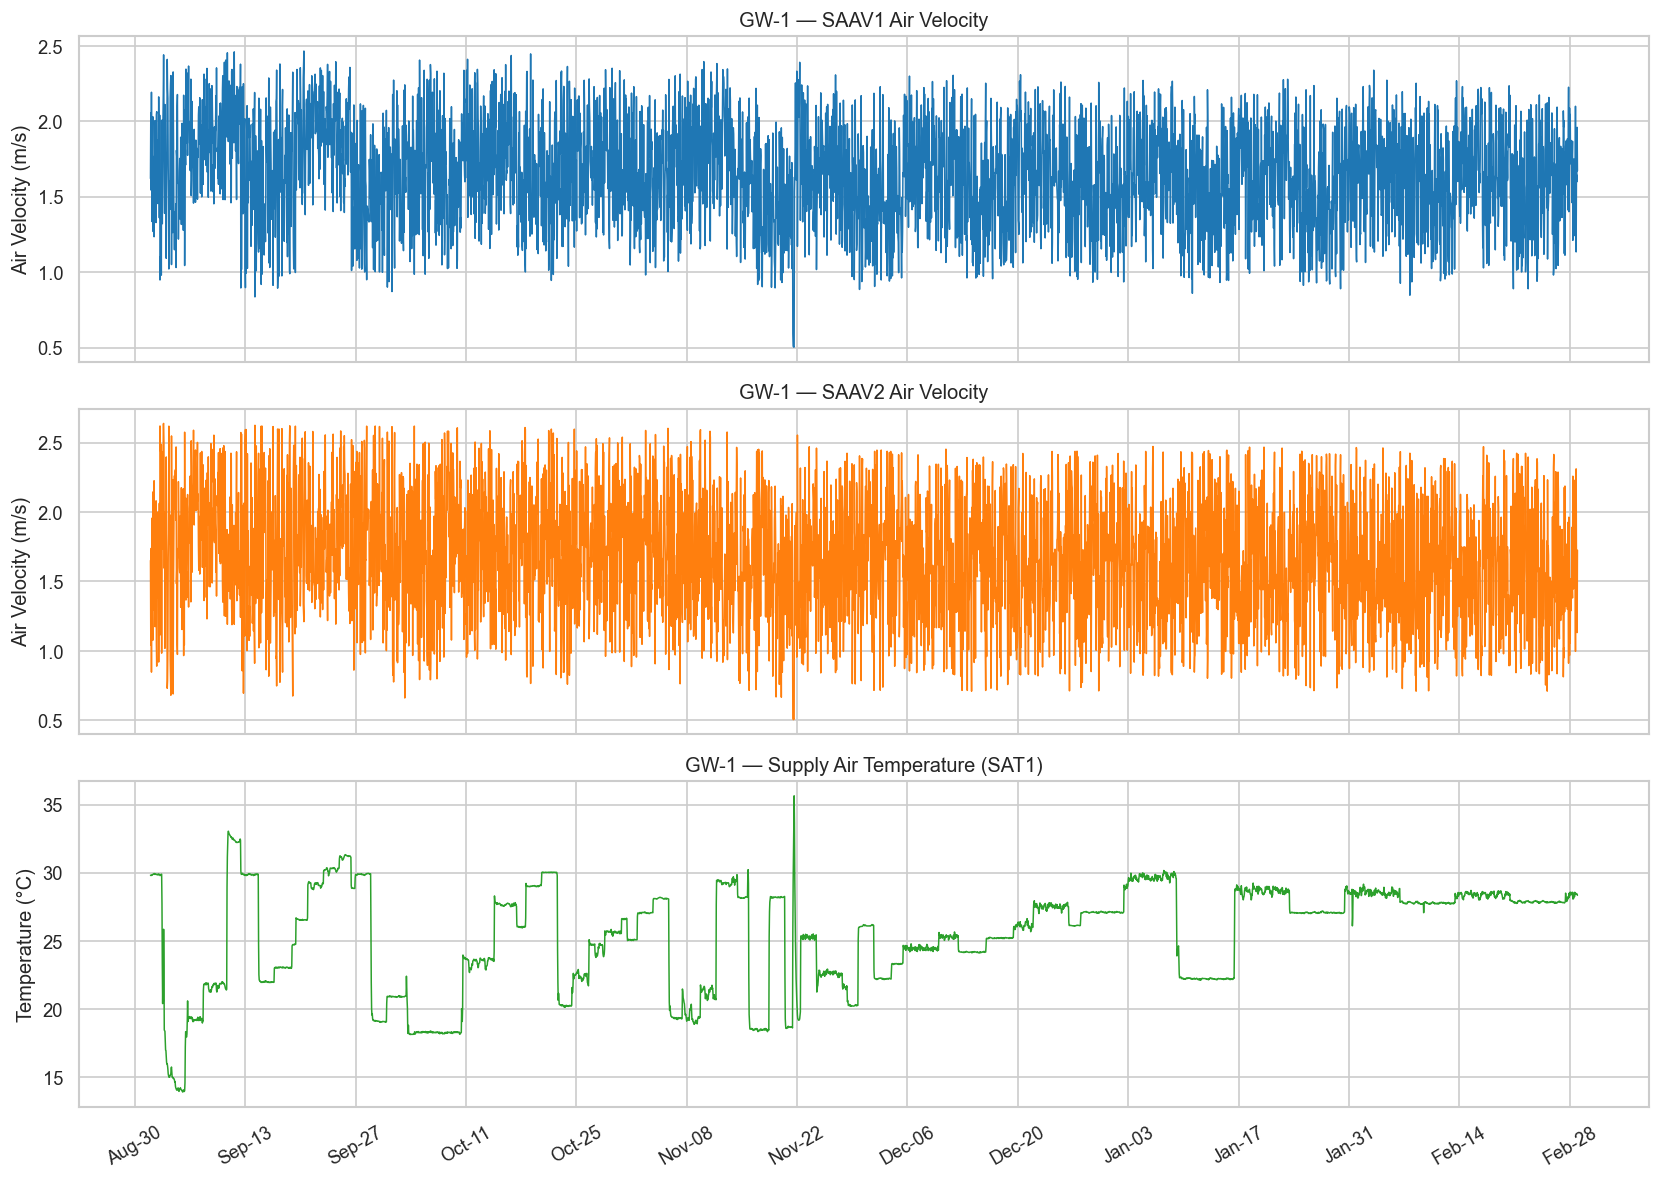

SAAV1 velocity: {'count': 507140.0, 'mean': 1.65, 'std': 0.86, 'min': 0.47, '25%': 0.75, '50%': 1.29, '75%': 2.52, 'max': 2.72}
SAAV2 velocity: {'count': 362556.0, 'mean': 1.67, 'std': 0.85, 'min': 0.5, '25%': 0.78, '50%': 2.15, '75%': 2.52, 'max': 2.73}
SAT1 temp:      {'count': 521233.0, 'mean': 25.41, 'std': 3.85, 'min': 13.83, '25%': 22.25, '50%': 26.56, '75%': 28.18, 'max': 42.44}


In [31]:
saav1 = load_gw(1, 'SAAV1', ['timestamp', 'velocity_ms'])
saav2 = load_gw(1, 'SAAV2', ['timestamp', 'velocity_ms'])
sat1  = load_gw(1, 'SAT1',  ['timestamp', 'temp_C'])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dh1 = saav1.set_index('timestamp')['velocity_ms'].resample('1h').mean()
axes[0].plot(dh1.index, dh1.values, color='#1f77b4', lw=0.9)
axes[0].set_ylabel('Air Velocity (m/s)')
axes[0].set_title('GW-1 — SAAV1 Air Velocity')

dh2 = saav2.set_index('timestamp')['velocity_ms'].resample('1h').mean()
axes[1].plot(dh2.index, dh2.values, color='#ff7f0e', lw=0.9)
axes[1].set_ylabel('Air Velocity (m/s)')
axes[1].set_title('GW-1 — SAAV2 Air Velocity')

dh = sat1.set_index('timestamp')['temp_C'].resample('1h').mean()
axes[2].plot(dh.index, dh.values, color='#2ca02c', lw=0.9)
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_title('GW-1 — Supply Air Temperature (SAT1)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"SAAV1 velocity: {saav1['velocity_ms'].describe().round(2).to_dict()}")
print(f"SAAV2 velocity: {saav2['velocity_ms'].describe().round(2).to_dict()}")
print(f"SAT1 temp:      {sat1['temp_C'].describe().round(2).to_dict()}")

### GW-2: Temp/Humidity (OATH, RATH, SATH) & Differential Pressure (DPS)

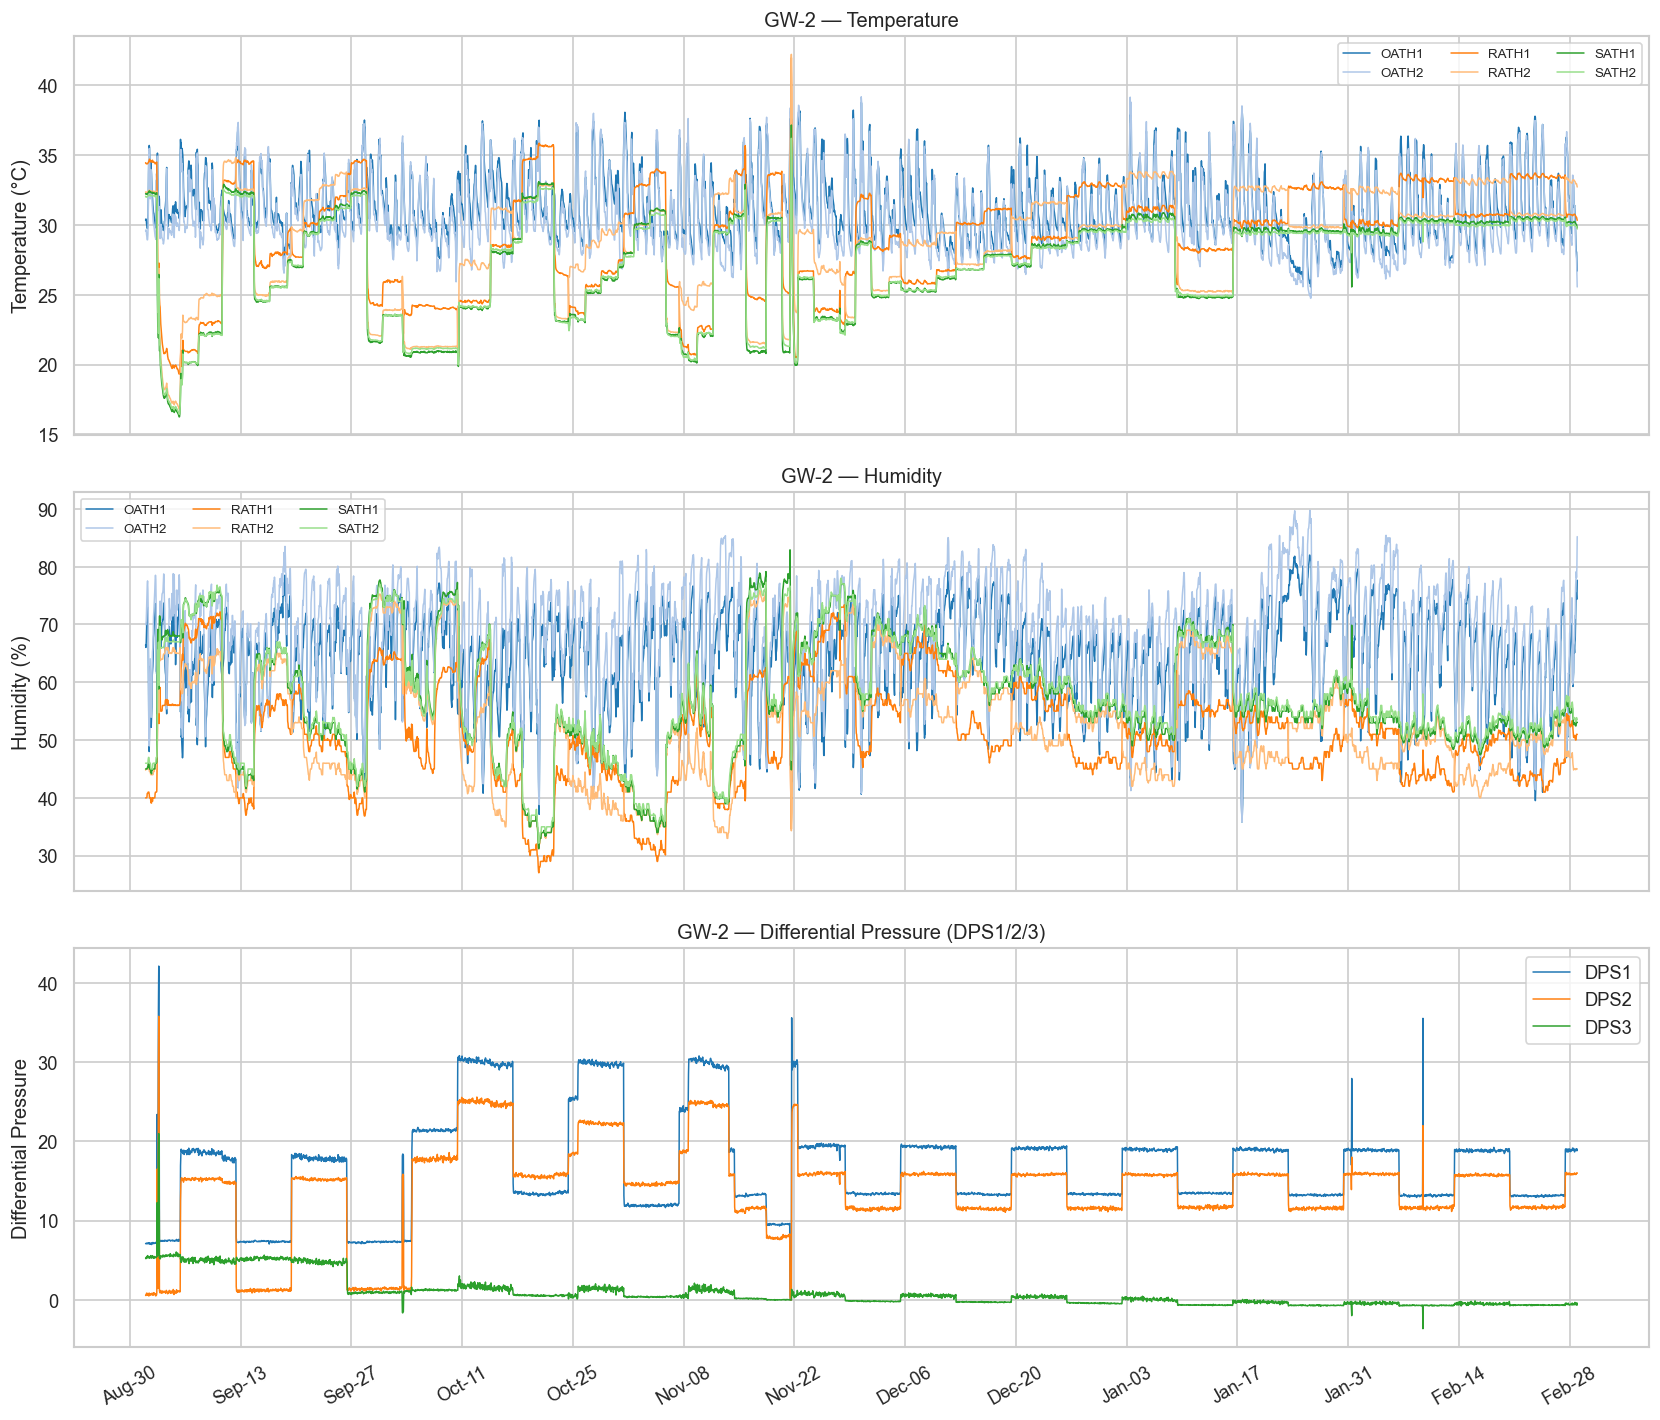

In [32]:
th_sensors_gw2 = ['OATH1', 'OATH2', 'RATH1', 'RATH2', 'SATH1', 'SATH2']
gw2_th = {s: load_gw(2, s, ['timestamp', 'temp_C', 'humidity_pct']) for s in th_sensors_gw2}
gw2_dps = {s: load_gw(2, s, ['timestamp', 'pressure']) for s in ['DPS1', 'DPS2', 'DPS3']}

colors_gw2 = ['#1f77b4','#aec7e8','#ff7f0e','#ffbb78','#2ca02c','#98df8a']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for (s, df), c in zip(gw2_th.items(), colors_gw2):
    dh = df.set_index('timestamp')[['temp_C', 'humidity_pct']].resample('1h').mean()
    axes[0].plot(dh.index, dh['temp_C'], label=s, lw=0.9, color=c)
    axes[1].plot(dh.index, dh['humidity_pct'], label=s, lw=0.9, color=c)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('GW-2 — Temperature')
axes[0].legend(ncol=3, fontsize=8)
axes[1].set_ylabel('Humidity (%)')
axes[1].set_title('GW-2 — Humidity')
axes[1].legend(ncol=3, fontsize=8)

for s, df in gw2_dps.items():
    dh = df.set_index('timestamp')['pressure'].resample('1h').mean()
    axes[2].plot(dh.index, dh.values, label=s, lw=0.9)
axes[2].set_ylabel('Differential Pressure')
axes[2].set_title('GW-2 — Differential Pressure (DPS1/2/3)')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### GW-3 & GW-4: Temperature & Pressure at cooling loop locations (DL/EL/LL/SL)

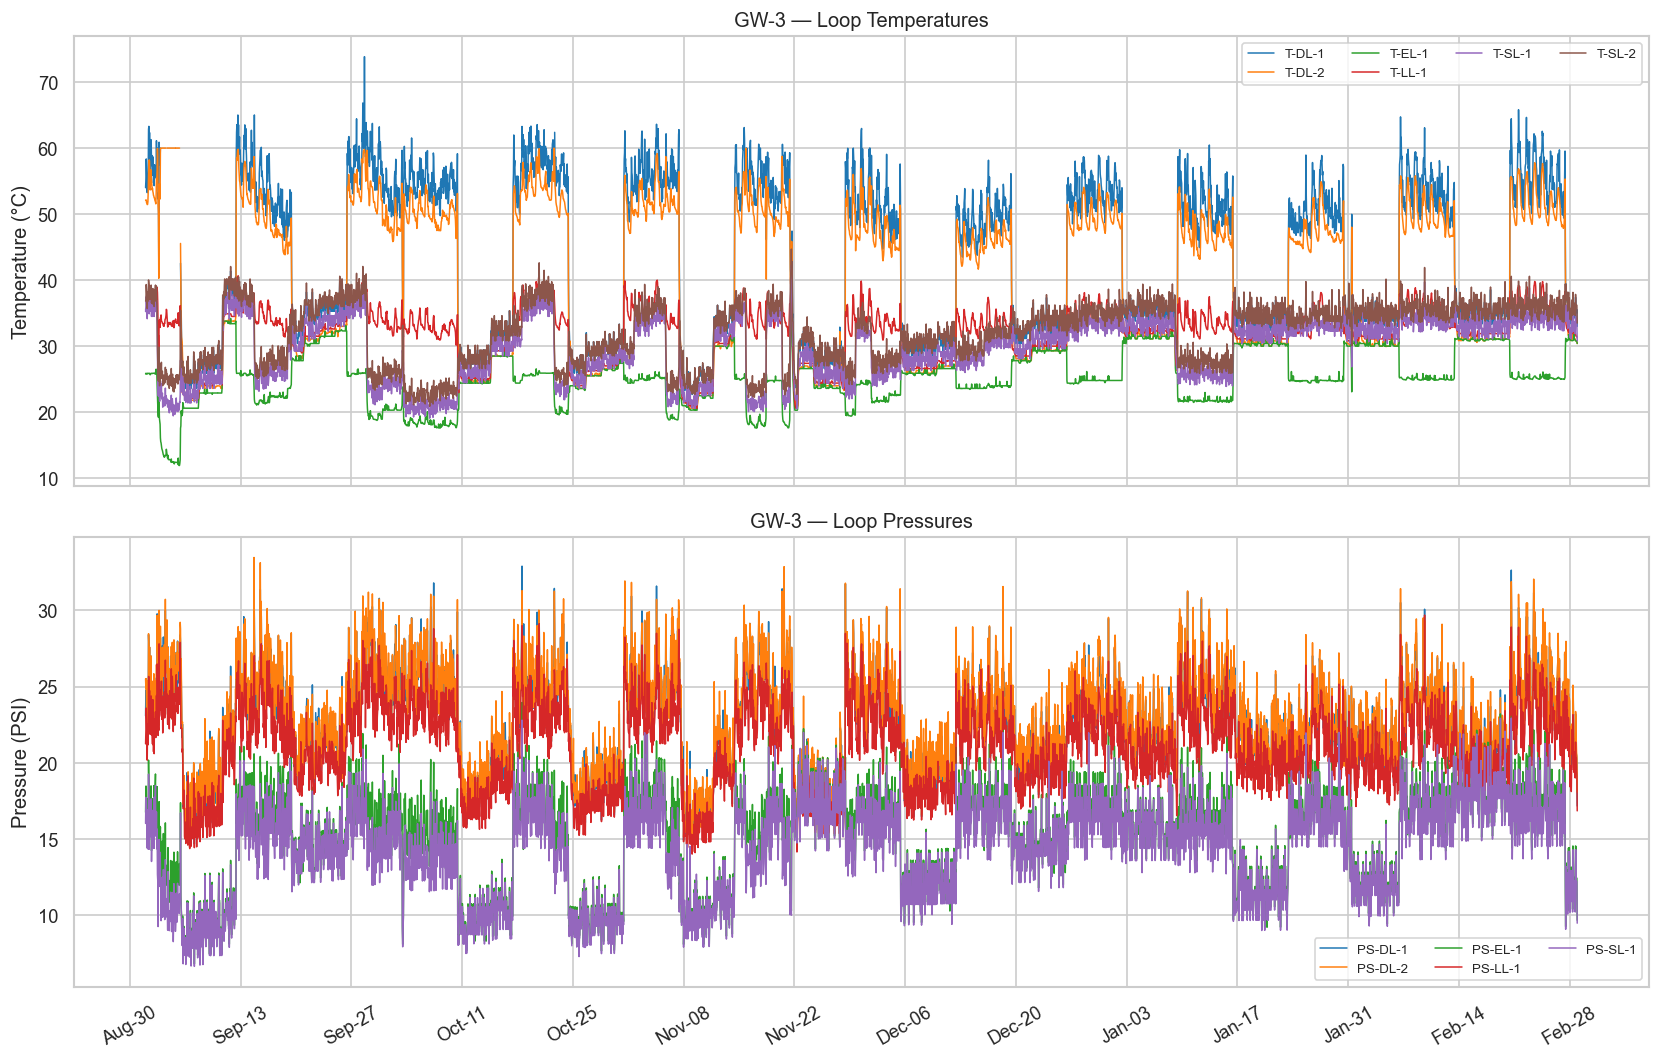

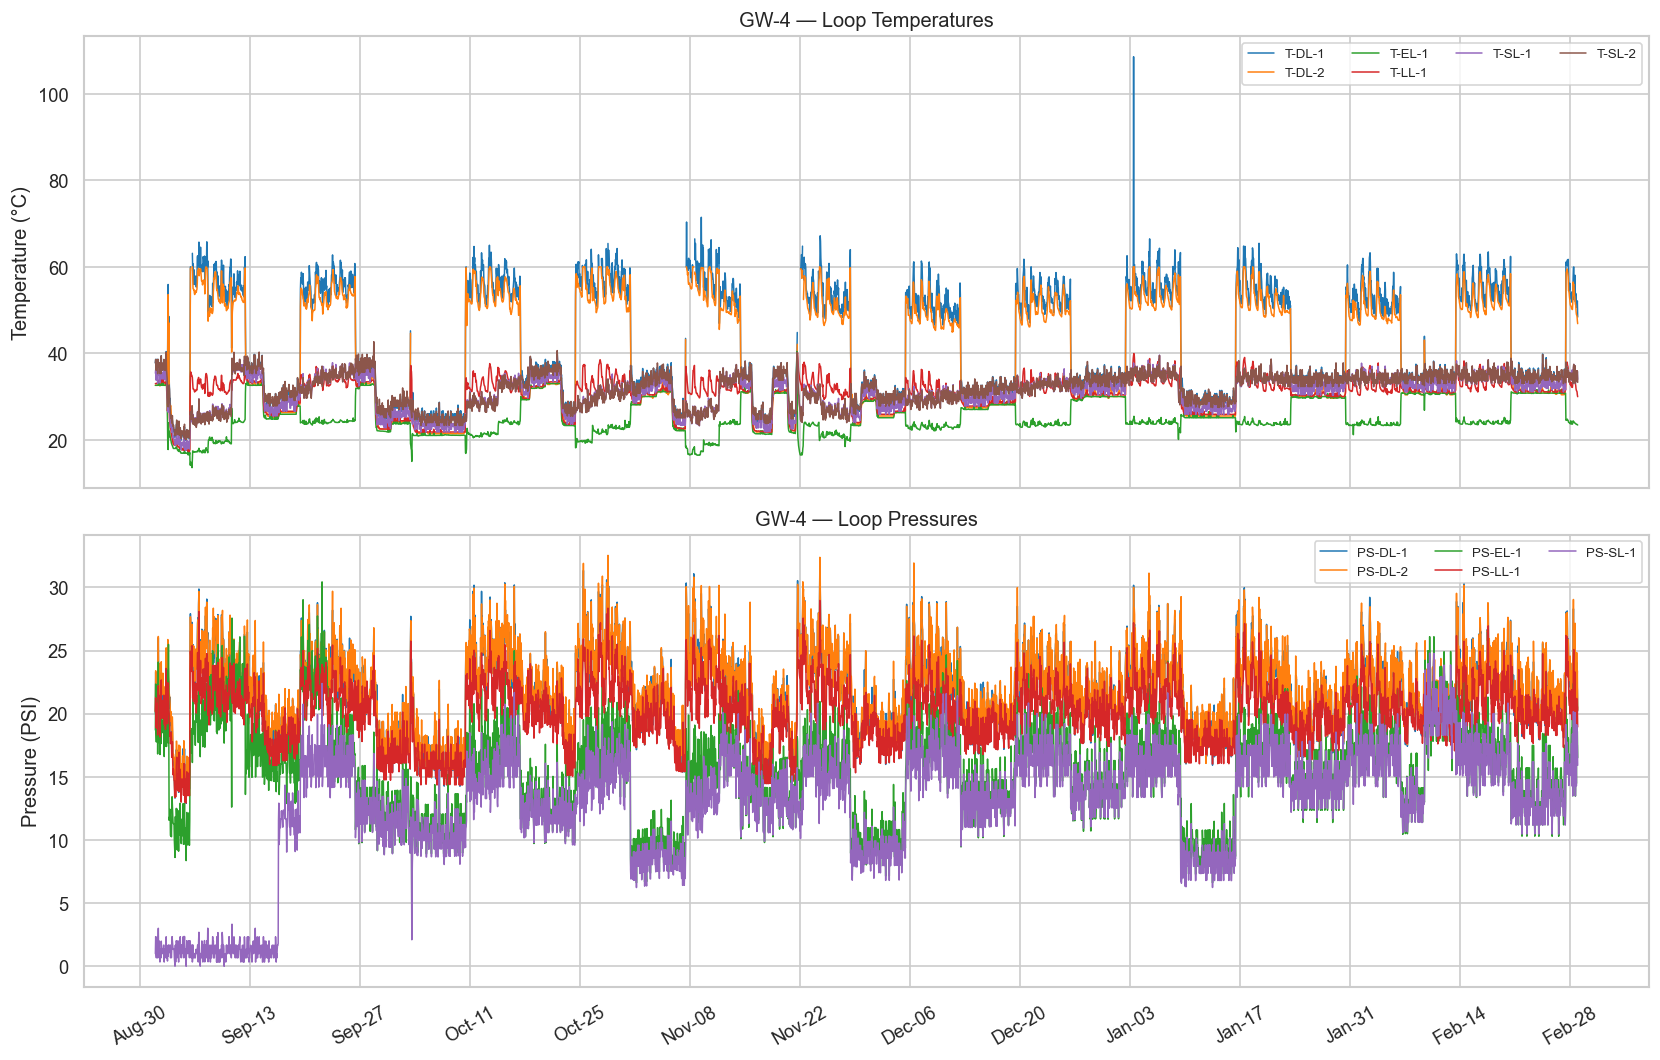

In [33]:
t_sensors  = ['T-DL-1','T-DL-2','T-EL-1','T-EL-2','T-LL-1','T-SL-1','T-SL-2']
ps_sensors = ['PS-DL-1','PS-DL-2','PS-EL-1','PS-LL-1','PS-SL-1']

for gw_num in [3, 4]:
    gw_t  = {s: load_gw(gw_num, s, ['timestamp', 'temp_C'])   for s in t_sensors}
    gw_ps = {s: load_gw(gw_num, s, ['timestamp', 'pressure']) for s in ps_sensors}

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    for s, df in gw_t.items():
        if df.empty: continue
        dh = df.set_index('timestamp')['temp_C'].resample('1h').mean()
        axes[0].plot(dh.index, dh.values, label=s, lw=0.9)
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_title(f'GW-{gw_num} — Loop Temperatures')
    axes[0].legend(ncol=4, fontsize=8)

    for s, df in gw_ps.items():
        if df.empty: continue
        dh = df.set_index('timestamp')['pressure'].resample('1h').mean()
        axes[1].plot(dh.index, dh.values, label=s, lw=0.9)
    axes[1].set_ylabel('Pressure (PSI)')
    axes[1].set_title(f'GW-{gw_num} — Loop Pressures')
    axes[1].legend(ncol=3, fontsize=8)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### GW-5: Cooling Unit Power (PCU-4 & PCU-5)

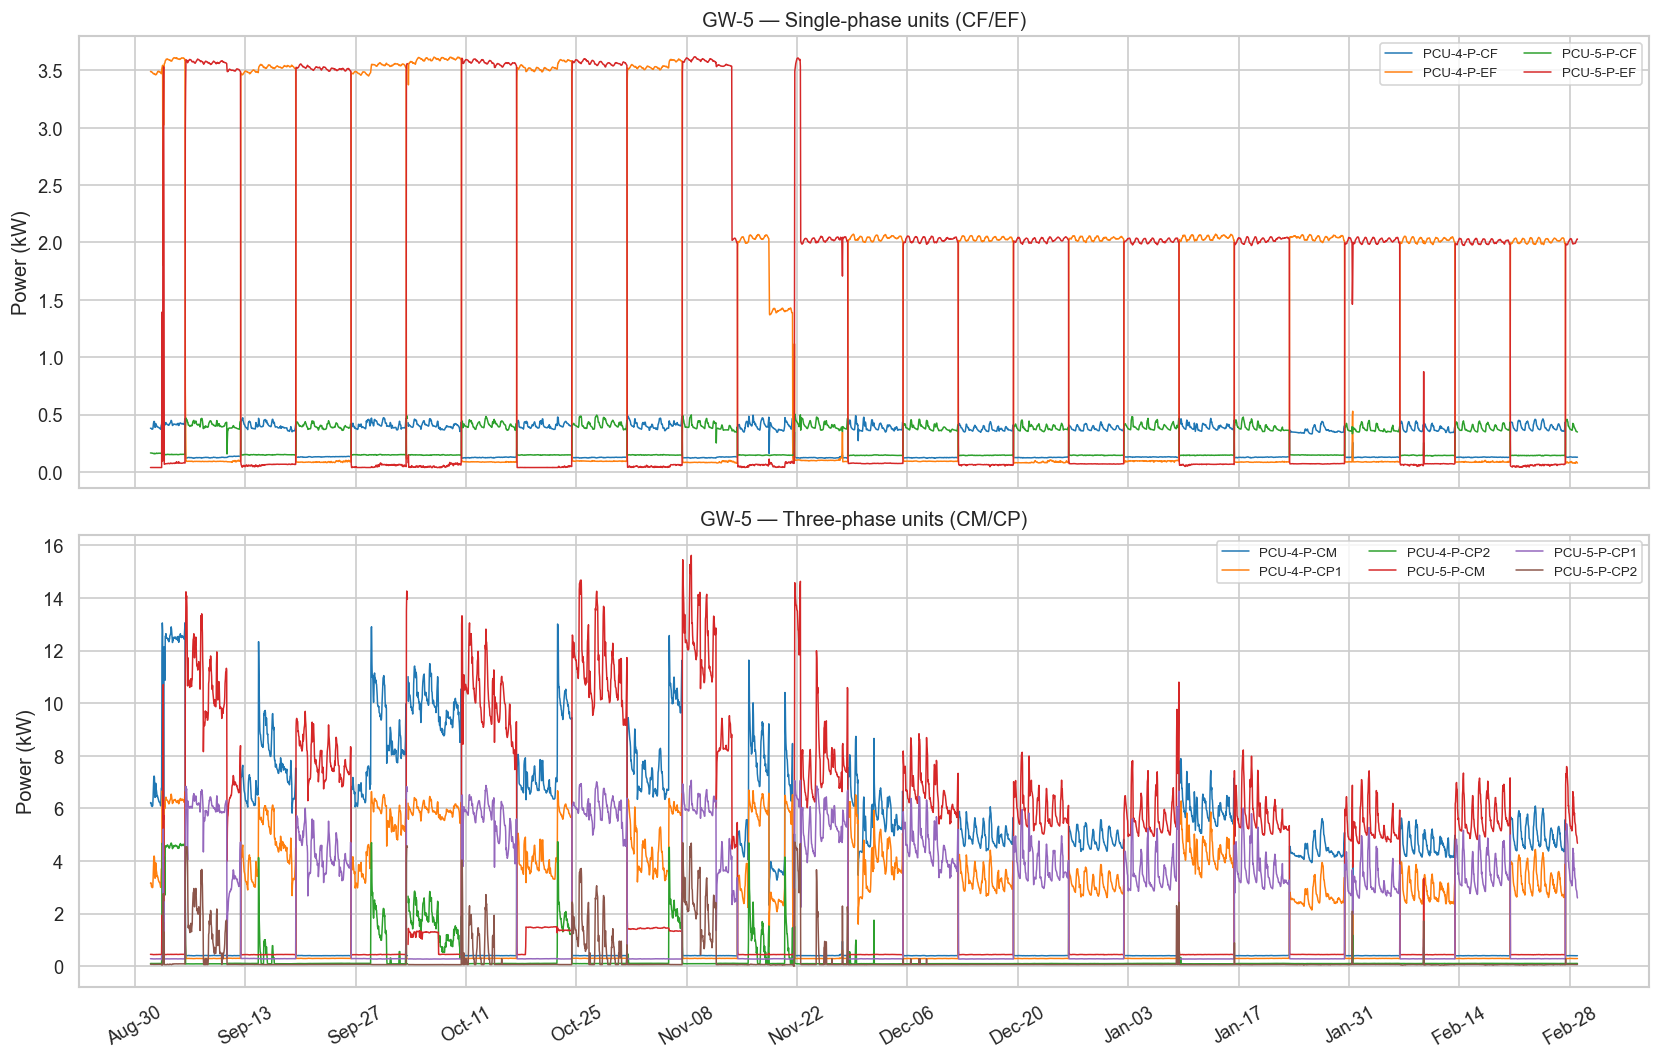

In [34]:
# Single-phase: CF (cooling fan), EF (exhaust fan)  → cols: W, V, A, PF, kWh
single_phase = ['PCU-4-P-CF','PCU-4-P-EF','PCU-5-P-CF','PCU-5-P-EF']
# Three-phase: CM (compressor), CP1/CP2 (pumps)     → cols: W, V_L1, V_L2, V_L3, kWh
three_phase  = ['PCU-4-P-CM','PCU-4-P-CP1','PCU-4-P-CP2',
                'PCU-5-P-CM','PCU-5-P-CP1','PCU-5-P-CP2']

sp_cols = ['timestamp','W','V','A','PF','kWh']
tp_cols = ['timestamp','W','V_L1','V_L2','V_L3','kWh']

gw5_sp = {s: load_gw(5, s, sp_cols) for s in single_phase}
gw5_tp = {s: load_gw(5, s, tp_cols) for s in three_phase}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for s, df in gw5_sp.items():
    dh = df.set_index('timestamp')['W'].resample('1h').mean() / 1000
    axes[0].plot(dh.index, dh.values, label=s, lw=0.9)
axes[0].set_ylabel('Power (kW)')
axes[0].set_title('GW-5 — Single-phase units (CF/EF)')
axes[0].legend(ncol=2, fontsize=8)

for s, df in gw5_tp.items():
    dh = df.set_index('timestamp')['W'].resample('1h').mean() / 1000
    axes[1].plot(dh.index, dh.values, label=s, lw=0.9)
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('GW-5 — Three-phase units (CM/CP)')
axes[1].legend(ncol=3, fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()